# Neural Network Models for Cascading Disaster Prediction

**Four architectures with Optuna hyperparameter tuning:**

| # | Model | Description |
|---|-------|-------------|
| 1 | **Baseline MLP** | 3-layer feed-forward network with full Optuna HP search |
| 2 | **MLP + Weather Embedding** | Same MLP backbone + a physics-informed weather embedding that encodes meteorological priors |
| 3 | **Autoencoder + Classifier** | Learns a compressed representation via reconstruction, then classifies from the bottleneck |
| 4 | **Autoencoder + Weather Embedding** | Autoencoder with weather-aware bottleneck + physics-informed embedding |

### Weather Embedding — Physics-Informed Design
The weather embedding is a **trainable module** that encodes domain knowledge:
- Separates raw features into **meteorological groups** (temporal/cyclical, spatial/geographic, severity/impact, event-type indicators, cascade-transition probabilities, historical context)
- Each group passes through its own sub-network with **physics-inspired activation constraints** (e.g., cyclical features use sine/cosine gating; spatial features use radial-basis-function-like transforms)
- Group embeddings are fused via a learned **attention-weighted combination**, giving the model an inductive bias toward physically meaningful feature interactions
- The fused embedding is concatenated with the raw features before the classifier head

In [130]:
import numpy as np
import pandas as pd
import pickle
import time
import warnings
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, hamming_loss,
    precision_recall_curve, confusion_matrix, roc_curve, auc
)

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__}  •  Device: {DEVICE}")

%matplotlib inline

PyTorch 2.8.0  •  Device: cpu


In [131]:
!pip install xgboost optuna scikit-learn matplotlib seaborn torch torchvision torchaudio --quiet

In [132]:
# ── Feature Toggle ──────────────────────────────────────────────────
# Set to True to EXCLUDE p(secondary | primary) features and
# total_cascade_probability.  Matches the XGBoost notebook toggle.
EXCLUDE_CASCADE_PROB_FEATURES = True

In [133]:
DATA_DIR = Path('../data/chronological_prepared_data')

X_train_raw = np.load(DATA_DIR / 'X_train.npy')
X_test_raw  = np.load(DATA_DIR / 'X_test.npy')
y_train_raw = np.load(DATA_DIR / 'y_train.npy')
y_test_raw  = np.load(DATA_DIR / 'y_test.npy')

with open(DATA_DIR / 'metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

feature_names = list(metadata['feature_names'])
target_names  = metadata['target_names']

print(f"Train : {X_train_raw.shape[0]:,} samples, {X_train_raw.shape[1]} features")
print(f"Test  : {X_test_raw.shape[0]:,} samples")
print(f"Labels: {len(target_names)}")
print(f"Split : {metadata.get('split_type', 'unknown')}")

# ── Optionally remove cascade-probability features ──────────────────
if EXCLUDE_CASCADE_PROB_FEATURES:
    keep_mask = []
    removed = []
    for i, name in enumerate(feature_names):
        if (name.startswith('p_') and name.endswith('_given_primary')) or name == 'total_cascade_probability':
            removed.append(name)
            keep_mask.append(False)
        else:
            keep_mask.append(True)
    keep_mask = np.array(keep_mask)
    X_train_raw = X_train_raw[:, keep_mask]
    X_test_raw  = X_test_raw[:, keep_mask]
    feature_names = [n for n, k in zip(feature_names, keep_mask) if k]
    print(f"\n⚠ Excluded {len(removed)} cascade-probability features:")
    for r in removed:
        print(f"  - {r}")
    print(f"Remaining features: {len(feature_names)}")

Train : 773,952 samples, 165 features
Test  : 193,489 samples
Labels: 26
Split : chronological

⚠ Excluded 30 cascade-probability features:
  - p_Avalanche_given_primary
  - p_Blizzard_given_primary
  - p_Coastal_Flood_given_primary
  - p_Cold_Wind_Chill_given_primary
  - p_Debris_Flow_given_primary
  - p_Dense_Fog_given_primary
  - p_Dust_Storm_given_primary
  - p_Excessive_Heat_given_primary
  - p_Extreme_Cold_Wind_Chill_given_primary
  - p_Flash_Flood_given_primary
  - p_Flood_given_primary
  - p_Frost_Freeze_given_primary
  - p_Hail_given_primary
  - p_Heat_given_primary
  - p_Heavy_Rain_given_primary
  - p_Heavy_Snow_given_primary
  - p_High_Surf_given_primary
  - p_High_Wind_given_primary
  - p_Ice_Storm_given_primary
  - p_Lightning_given_primary
  - p_Marine_Hail_given_primary
  - p_Marine_Thunderstorm_Wind_given_primary
  - p_Rip_Current_given_primary
  - p_Storm_Surge_Tide_given_primary
  - p_Thunderstorm_Wind_given_primary
  - p_Tornado_given_primary
  - p_Waterspout_given_p

In [134]:
# ── Build feature-group indices for the Weather Embedding ──────────────
# The physics-informed embedding needs to know which columns belong to which
# meteorological concept so it can apply appropriate inductive biases.

def build_feature_groups(feature_names):
    """Partition feature indices into semantically meaningful groups."""
    groups = {
        'temporal_cyclical': [],   # sin/cos encoded time features
        'temporal_ordinal':  [],   # day_of_year, hour, etc.
        'spatial':           [],   # lat, lon, coastal, coordinate features
        'severity_impact':   [],   # damage, injuries, deaths, severity scores
        'event_type':        [],   # one-hot event-type indicators + group flags
        'cascade_prob':      [],   # p_*_given_primary transition probabilities
        'historical':        [],   # rolling windows, days_since, cascade counts
        'other':             [],   # everything else
    }
    
    cyclical_kw = ['_sin', '_cos']
    temporal_kw = ['day_of_year', 'day_of_week', 'month', 'hour', 'event_duration']
    spatial_kw  = ['lat', 'lon', 'coastal', 'coordinate', 'BEGIN_LAT', 'BEGIN_LON',
                   'LATITUDE', 'LONGITUDE', 'abs_latitude', 'begin_range',
                   'event_path_length', 'is_marine', 'is_zone']
    severity_kw = ['damage', 'injur', 'death', 'fatal', 'severity', 'magnitude',
                   'log_damage', 'has_magnitude', 'is_severe_wind', 'is_significant_hail']
    etype_kw    = ['etype_', 'is_hurricane', 'is_flood_type', 'is_winter_type',
                   'is_convective', 'event_rarity']
    cascade_kw  = ['p_', '_given_primary', 'total_cascade_prob']
    hist_kw     = ['events_last_', 'damage_last_', 'max_severity_last_', 'cascades_',
                   'days_since_', 'recent_event_density', 'location_event_count',
                   'location_avg', 'location_cascade', 'state_avg', 'state_cascade',
                   'event_type_avg']
    
    for i, name in enumerate(feature_names):
        nl = name.lower()
        if any(k in nl for k in cyclical_kw):
            groups['temporal_cyclical'].append(i)
        elif any(k in nl for k in temporal_kw):
            groups['temporal_ordinal'].append(i)
        elif name.startswith('p_') and 'given_primary' in nl:
            groups['cascade_prob'].append(i)
        elif any(k in nl for k in spatial_kw):
            groups['spatial'].append(i)
        elif any(k in nl for k in severity_kw):
            groups['severity_impact'].append(i)
        elif any(k in nl for k in etype_kw):
            groups['event_type'].append(i)
        elif any(k in nl for k in hist_kw):
            groups['historical'].append(i)
        else:
            groups['other'].append(i)
    
    # Merge tiny groups into 'other'
    for k in list(groups.keys()):
        if len(groups[k]) == 0 and k != 'other':
            del groups[k]
    
    return groups

FEATURE_GROUPS = build_feature_groups(feature_names)
print("Feature groups:")
for g, idx_list in FEATURE_GROUPS.items():
    print(f"  {g:25s} : {len(idx_list):3d} features")
print(f"  {'TOTAL':25s} : {sum(len(v) for v in FEATURE_GROUPS.values()):3d}")

Feature groups:
  temporal_cyclical         :   6 features
  temporal_ordinal          :   5 features
  spatial                   :  16 features
  severity_impact           :  31 features
  event_type                :  59 features
  historical                :   6 features
  other                     :  12 features
  TOTAL                     : 135


In [167]:
# Visualize feature groups as a colored table
import pandas as pd
from IPython.display import display

feature_group_table = []
for group, idxs in FEATURE_GROUPS.items():
    examples = [feature_names[i] for i in idxs[:3]]  # up to 3 examples
    feature_group_table.append({
        'Feature Group': group,
        '# Features': len(idxs),
        'Examples': ', '.join(examples) if examples else '(none)'
    })

fg_df = pd.DataFrame(feature_group_table)

# Style: white background, red text, horizontal lines
styled = fg_df.style.format({'# Features': '{:d}'}) \
    .applymap(lambda v: 'color: red; background-color: #fff; border-bottom: 2px solid #ccc')

print("Feature Groups Table:")
display(styled)

# Check for overlaps
all_idxs = sum([idxs for idxs in FEATURE_GROUPS.values()], [])
unique_idxs = set(all_idxs)
if len(all_idxs) == len(unique_idxs):
    print("\nNo feature overlaps: each feature is assigned to only one group.")
else:
    print("\nWarning: Some features are assigned to multiple groups!")

Feature Groups Table:


,Feature Group,# Features,Examples
0,temporal_cyclical,6,"month_sin, month_cos, hour_sin"
1,temporal_ordinal,5,"event_duration_hours, month, hour"
2,spatial,16,"BEGIN_LAT, BEGIN_LON, END_LAT"
3,severity_impact,31,"MAGNITUDE, INJURIES_DIRECT, INJURIES_INDIRECT"
4,event_type,59,"etype_Astronomical Low Tide, etype_Avalanche, etype_Blizzard"
5,historical,6,"events_last_7d, events_last_30d, recent_event_density"
6,other,12,"STATE_FIPS, CZ_FIPS, END_RANGE"



No feature overlaps: each feature is assigned to only one group.


In [135]:
# ── PyTorch data loaders ────────────────────────────────────────────────
def make_loaders(X_tr, y_tr, X_val, y_val, X_te, y_te, batch_size=1024):
    train_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                             torch.tensor(y_tr, dtype=torch.float32))
    val_ds   = TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                             torch.tensor(y_val, dtype=torch.float32))
    test_ds  = TensorDataset(torch.tensor(X_te, dtype=torch.float32),
                             torch.tensor(y_te, dtype=torch.float32))
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=False)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)
    return train_loader, val_loader, test_loader

print("Data loader factory ready.")

Data loader factory ready.


In [136]:
# ── Training loop (shared by all models) ───────────────────────────────
def train_model(model, train_loader, val_loader, pos_weight_tensor,
                lr=1e-3, weight_decay=1e-4, epochs=80, patience=12,
                verbose=True, recon_weight=0.0):
    """Train a model with BCE loss, optional reconstruction loss, early stopping."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    recon_criterion = nn.MSELoss()
    
    best_val_f1 = -1
    best_state = None
    wait = 0
    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    
    for epoch in range(1, epochs + 1):
        # ── Train ──
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            
            out = model(xb)
            if isinstance(out, tuple):  # (logits, reconstruction)
                logits, recon = out
                loss = criterion(logits, yb) + recon_weight * recon_criterion(recon, xb)
            else:
                logits = out
                loss = criterion(logits, yb)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        epoch_loss /= len(train_loader.dataset)
        
        # ── Validate ──
        model.eval()
        val_loss = 0
        all_logits, all_y = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                if isinstance(out, tuple):
                    logits, recon = out
                    loss = criterion(logits, yb) + recon_weight * recon_criterion(recon, xb)
                else:
                    logits = out
                    loss = criterion(logits, yb)
                val_loss += loss.item() * xb.size(0)
                all_logits.append(logits.cpu())
                all_y.append(yb.cpu())
        val_loss /= len(val_loader.dataset)
        
        all_logits = torch.cat(all_logits).numpy()
        all_y = torch.cat(all_y).numpy()
        preds = (torch.sigmoid(torch.tensor(all_logits)).numpy() >= 0.5).astype(int)
        val_f1 = f1_score(all_y, preds, average='macro', zero_division=0)
        
        scheduler.step(val_f1)
        history['train_loss'].append(epoch_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        
        if verbose and (epoch % 10 == 0 or epoch == 1 or wait == 0):
            marker = ' ★' if wait == 0 else ''
            print(f"  Epoch {epoch:3d}  loss={epoch_loss:.4f}  val_loss={val_loss:.4f}  "
                  f"val_f1={val_f1:.4f}{marker}")
        
        if wait >= patience:
            if verbose:
                print(f"  Early stop at epoch {epoch} (best val_f1={best_val_f1:.4f})")
            break
    
    model.load_state_dict(best_state)
    model.to(DEVICE)
    return model, history, best_val_f1


# ── Prediction & threshold tuning ──────────────────────────────────────
def predict_proba(model, loader):
    """Return sigmoid probabilities."""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            out = model(xb)
            logits = out[0] if isinstance(out, tuple) else out
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(all_probs, axis=0)


def tune_thresholds(y_true, y_prob, min_thresh=0.05):
    """Per-label threshold tuning on validation set (maximise F1)."""
    n_labels = y_true.shape[1]
    thresholds = np.full(n_labels, 0.5)
    for i in range(n_labels):
        if y_true[:, i].sum() == 0:
            continue
        precs, recs, ths = precision_recall_curve(y_true[:, i], y_prob[:, i])
        f1s = 2 * precs * recs / (precs + recs + 1e-8)
        best = np.argmax(f1s)
        if best < len(ths):
            thresholds[i] = max(ths[best], min_thresh)
    return thresholds


def evaluate_model(model_name, y_true, y_prob, thresholds, target_names):
    """Compute and return a results dict + per-label DataFrame."""
    y_pred = (y_prob >= thresholds).astype(int)
    overall = {
        'model': model_name,
        'f1_weighted':        f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_macro':           f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'f1_micro':           f1_score(y_true, y_pred, average='micro',    zero_division=0),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision_macro':    precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_weighted':    recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_macro':       recall_score(y_true, y_pred, average='macro',    zero_division=0),
        'hamming_loss':       hamming_loss(y_true, y_pred),
        'subset_accuracy':    (y_true == y_pred).all(axis=1).mean(),
    }
    # AUCPR (threshold-independent, computed from probabilities)
    try:
        overall['aucpr_weighted'] = average_precision_score(y_true, y_prob, average='weighted')
        overall['aucpr_macro']    = average_precision_score(y_true, y_prob, average='macro')
    except Exception:
        overall['aucpr_weighted'] = 0.0
        overall['aucpr_macro']    = 0.0
    # ROC-AUC
    try:
        per_label_roc = []
        for j in range(y_true.shape[1]):
            if y_true[:, j].sum() > 0 and y_true[:, j].sum() < len(y_true[:, j]):
                fpr, tpr, _ = roc_curve(y_true[:, j], y_prob[:, j])
                per_label_roc.append(auc(fpr, tpr))
        overall['roc_auc_macro'] = np.mean(per_label_roc) if per_label_roc else 0.0
    except Exception:
        overall['roc_auc_macro'] = 0.0

    per_label = []
    for j, lbl in enumerate(target_names):
        sup = int(y_true[:, j].sum())
        f1   = f1_score(y_true[:, j], y_pred[:, j], zero_division=0)
        prec = precision_score(y_true[:, j], y_pred[:, j], zero_division=0)
        rec  = recall_score(y_true[:, j], y_pred[:, j], zero_division=0)
        try:
            prauc = average_precision_score(y_true[:, j], y_prob[:, j])
        except Exception:
            prauc = 0.0
        try:
            if sup > 0 and sup < len(y_true[:, j]):
                fpr, tpr, _ = roc_curve(y_true[:, j], y_prob[:, j])
                roc_auc_val = auc(fpr, tpr)
            else:
                roc_auc_val = 0.0
        except Exception:
            roc_auc_val = 0.0
        per_label.append(dict(label=lbl, support=sup, f1=f1, precision=prec,
                              recall=rec, pr_auc=prauc, roc_auc=roc_auc_val))
    return overall, pd.DataFrame(per_label)


print("Training & evaluation utilities loaded.")

Training & evaluation utilities loaded.


---
## 3. Model Definitions

### 3a. Physics-Informed Weather Embedding

This reusable module encodes domain knowledge about meteorological features:
- **Group-specific sub-networks** with tailored activations
- **Cyclical gating** for temporal features (preserves periodicity)
- **RBF-like spatial transform** (latitude/longitude → distance-based representation)
- **Learned attention** over groups for fusion

In [137]:
class CyclicalGate(nn.Module):
    """Gating layer that preserves cyclical structure: output = x * sigmoid(Wx+b) + sin(Vx+c)."""
    def __init__(self, dim):
        super().__init__()
        self.gate_linear = nn.Linear(dim, dim)
        self.wave_linear = nn.Linear(dim, dim)

    def forward(self, x):
        return x * torch.sigmoid(self.gate_linear(x)) + torch.sin(self.wave_linear(x))


class RBFSpatialTransform(nn.Module):
    """Radial-basis-function inspired layer for spatial coordinates.
    Learns K centres and widths; outputs exp(-||x - c_k||^2 / (2*sigma_k^2))."""
    def __init__(self, in_dim, n_centres=16):
        super().__init__()
        self.centres = nn.Parameter(torch.randn(n_centres, in_dim) * 0.5)
        self.log_sigma = nn.Parameter(torch.zeros(n_centres))
    
    def forward(self, x):
        # x: (B, in_dim), centres: (K, in_dim)
        diff = x.unsqueeze(1) - self.centres.unsqueeze(0)  # (B, K, in_dim)
        sq_dist = (diff ** 2).sum(dim=-1)  # (B, K)
        sigma2 = (2 * self.log_sigma.exp() ** 2).clamp(min=1e-4)
        return torch.exp(-sq_dist / sigma2)  # (B, K)


class PhysicsInformedWeatherEmbedding(nn.Module):
    """Encode raw features into a physics-aware embedding.
    
    Each feature group passes through a specialised sub-network:
    - temporal_cyclical → CyclicalGate
    - spatial           → RBFSpatialTransform + linear
    - cascade_prob      → softmax-normalised before linear (probability simplex)
    - others            → standard linear+GELU blocks
    
    Group embeddings are fused via learned attention weights.
    """
    def __init__(self, feature_groups, group_embed_dim=32, n_rbf_centres=16):
        super().__init__()
        self.feature_groups = feature_groups
        self.group_names = sorted(feature_groups.keys())
        self.group_embed_dim = group_embed_dim
        
        self.sub_networks = nn.ModuleDict()
        for gname in self.group_names:
            in_dim = len(feature_groups[gname])
            if in_dim == 0:
                continue
            if gname == 'temporal_cyclical':
                self.sub_networks[gname] = nn.Sequential(
                    nn.Linear(in_dim, group_embed_dim),
                    CyclicalGate(group_embed_dim),
                    nn.Linear(group_embed_dim, group_embed_dim),
                )
            elif gname == 'spatial':
                self.sub_networks[gname] = nn.Sequential(
                    RBFSpatialTransform(in_dim, n_centres=n_rbf_centres),
                    nn.Linear(n_rbf_centres, group_embed_dim),
                    nn.GELU(),
                )
            elif gname == 'cascade_prob':
                # Treat cascade transition probabilities as a probability vector
                self.sub_networks[gname] = nn.Sequential(
                    nn.Softmax(dim=-1),
                    nn.Linear(in_dim, group_embed_dim),
                    nn.GELU(),
                    nn.Linear(group_embed_dim, group_embed_dim),
                )
            else:  # severity_impact, event_type, historical, other, temporal_ordinal
                self.sub_networks[gname] = nn.Sequential(
                    nn.Linear(in_dim, group_embed_dim),
                    nn.GELU(),
                    nn.Linear(group_embed_dim, group_embed_dim),
                )
        
        n_groups = len(self.sub_networks)
        # Attention over group embeddings
        self.attn_query = nn.Linear(group_embed_dim, 1, bias=False)
        self.fuse = nn.Linear(n_groups * group_embed_dim, n_groups * group_embed_dim)
        self.out_dim = n_groups * group_embed_dim
    
    def forward(self, x):
        group_embeds = []
        for gname in self.group_names:
            if gname not in self.sub_networks:
                continue
            idx = self.feature_groups[gname]
            x_group = x[:, idx]
            group_embeds.append(self.sub_networks[gname](x_group))
        
        # Stack: (B, n_groups, embed_dim)
        stacked = torch.stack(group_embeds, dim=1)
        # Attention scores
        attn_scores = self.attn_query(stacked).squeeze(-1)  # (B, n_groups)
        attn_weights = F.softmax(attn_scores, dim=-1).unsqueeze(-1)  # (B, n_groups, 1)
        # Weighted embeddings, then flatten
        weighted = (stacked * attn_weights).reshape(x.size(0), -1)  # (B, n_groups*embed_dim)
        return F.gelu(self.fuse(weighted))


print(f"PhysicsInformedWeatherEmbedding defined  "
      f"({len([g for g in FEATURE_GROUPS if len(FEATURE_GROUPS[g])>0])} active groups)")

PhysicsInformedWeatherEmbedding defined  (7 active groups)


### 3b. Model 1 — Baseline MLP (3-layer)

In [138]:
class BaselineMLP(nn.Module):
    """Simple 3-hidden-layer MLP with dropout and batch normalisation."""
    def __init__(self, in_dim, out_dim, h1=256, h2=128, h3=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, h1), nn.BatchNorm1d(h1), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(h1, h2),     nn.BatchNorm1d(h2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(h2, h3),     nn.BatchNorm1d(h3), nn.GELU(), nn.Dropout(dropout * 0.5),
            nn.Linear(h3, out_dim),
        )
    def forward(self, x):
        return self.net(x)

print("Model 1: BaselineMLP defined.")

Model 1: BaselineMLP defined.


### 3c. Model 2 — MLP + Weather Embedding

In [139]:
class WeatherMLP(nn.Module):
    """MLP that concatenates physics-informed weather embedding with raw features."""
    def __init__(self, in_dim, out_dim, feature_groups,
                 group_embed_dim=32, h1=256, h2=128, h3=64, dropout=0.3):
        super().__init__()
        self.weather_embed = PhysicsInformedWeatherEmbedding(
            feature_groups, group_embed_dim=group_embed_dim
        )
        combined_dim = in_dim + self.weather_embed.out_dim
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, h1), nn.BatchNorm1d(h1), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(h1, h2),           nn.BatchNorm1d(h2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(h2, h3),           nn.BatchNorm1d(h3), nn.GELU(), nn.Dropout(dropout * 0.5),
            nn.Linear(h3, out_dim),
        )
    
    def forward(self, x):
        w_emb = self.weather_embed(x)
        combined = torch.cat([x, w_emb], dim=-1)
        return self.classifier(combined)

print("Model 2: WeatherMLP defined.")

Model 2: WeatherMLP defined.


### 3d. Model 3 — Autoencoder + Classifier

In [140]:
class AutoencoderClassifier(nn.Module):
    """Learns a compressed bottleneck via reconstruction, then classifies from it.
    
    Architecture:
        Encoder: in_dim → enc1 → enc2 → bottleneck_dim
        Decoder: bottleneck_dim → enc2 → enc1 → in_dim  (reconstruction)
        Classifier: bottleneck_dim → cls_h → out_dim
    
    Returns (logits, reconstruction) during training.
    """
    def __init__(self, in_dim, out_dim, enc1=256, enc2=128, bottleneck=64,
                 cls_hidden=64, dropout=0.3):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, enc1), nn.BatchNorm1d(enc1), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(enc1, enc2),   nn.BatchNorm1d(enc2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(enc2, bottleneck), nn.BatchNorm1d(bottleneck), nn.GELU(),
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, enc2), nn.GELU(),
            nn.Linear(enc2, enc1),       nn.GELU(),
            nn.Linear(enc1, in_dim),
        )
        # Classifier head from bottleneck
        self.classifier = nn.Sequential(
            nn.Linear(bottleneck, cls_hidden), nn.GELU(), nn.Dropout(dropout * 0.5),
            nn.Linear(cls_hidden, out_dim),
        )
    
    def encode(self, x):
        return self.encoder(x)
    
    def forward(self, x):
        z = self.encode(x)
        recon = self.decoder(z)
        logits = self.classifier(z)
        return logits, recon

print("Model 3: AutoencoderClassifier defined.")

Model 3: AutoencoderClassifier defined.


### 3e. Model 4 — Autoencoder + Weather Embedding

In [141]:
class WeatherAutoencoder(nn.Module):
    """Autoencoder whose bottleneck is enriched with the physics-informed weather embedding.
    
    Architecture:
        Weather Embed: features → group sub-nets → attention-fused vector
        Encoder: [raw_features | weather_embed] → enc1 → enc2 → bottleneck
        Decoder: bottleneck → dec2 → dec1 → in_dim  (reconstructs raw features only)
        Classifier: bottleneck → cls_h → out_dim
    """
    def __init__(self, in_dim, out_dim, feature_groups,
                 group_embed_dim=32, enc1=256, enc2=128, bottleneck=64,
                 cls_hidden=64, dropout=0.3):
        super().__init__()
        self.weather_embed = PhysicsInformedWeatherEmbedding(
            feature_groups, group_embed_dim=group_embed_dim
        )
        combined_in = in_dim + self.weather_embed.out_dim
        
        self.encoder = nn.Sequential(
            nn.Linear(combined_in, enc1), nn.BatchNorm1d(enc1), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(enc1, enc2),        nn.BatchNorm1d(enc2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(enc2, bottleneck),  nn.BatchNorm1d(bottleneck), nn.GELU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, enc2),  nn.GELU(),
            nn.Linear(enc2, enc1),        nn.GELU(),
            nn.Linear(enc1, in_dim),  # reconstruct raw features (no embedding)
        )
        self.classifier = nn.Sequential(
            nn.Linear(bottleneck, cls_hidden), nn.GELU(), nn.Dropout(dropout * 0.5),
            nn.Linear(cls_hidden, out_dim),
        )
    
    def forward(self, x):
        w_emb = self.weather_embed(x)
        combined = torch.cat([x, w_emb], dim=-1)
        z = self.encoder(combined)
        recon = self.decoder(z)  # reconstructs raw x, not the combined input
        logits = self.classifier(z)
        return logits, recon

print("Model 4: WeatherAutoencoder defined.")

Model 4: WeatherAutoencoder defined.


---
## 4. Hyperparameter Tuning with Optuna

Each model gets its own Optuna study. We use **Tree-structured Parzen Estimator (TPE)**
with 30 trials per model. The objective is to maximise **macro F1 on the validation set**.

In [142]:
N_OPTUNA_TRIALS = 20
TUNING_EPOCHS   = 40           # shorter training during search
TUNING_PATIENCE = 8
FINAL_EPOCHS    = 80
FINAL_PATIENCE  = 15

# We'll collect all results here
all_results = {}   # model_name -> (overall_dict, per_label_df, history, thresholds)

print(f"Optuna config: {N_OPTUNA_TRIALS} trials, {TUNING_EPOCHS} epochs/trial")

Optuna config: 20 trials, 40 epochs/trial


In [143]:
# ── Chronological train/val split + scaling ────────────────────────────
# Reserve the last 20% of training data as validation (preserves time order).
from sklearn.preprocessing import StandardScaler

VAL_FRAC = 0.2
n_total = X_train_raw.shape[0]
n_val   = int(n_total * VAL_FRAC)
n_train = n_total - n_val

X_tr_raw = X_train_raw[:n_train]
y_tr_raw = y_train_raw[:n_train]
X_val_raw = X_train_raw[n_train:]
y_val_raw = y_train_raw[n_train:]

# Scale features (fit on train only)
scaler = StandardScaler()
X_tr_np  = scaler.fit_transform(X_tr_raw).astype(np.float32)
X_val_np = scaler.transform(X_val_raw).astype(np.float32)
X_te_np  = scaler.transform(X_test_raw).astype(np.float32)

y_tr_np  = y_tr_raw.astype(np.float32)
y_val_np = y_val_raw.astype(np.float32)

n_features = X_tr_np.shape[1]
n_labels   = y_tr_np.shape[1]

# Compute pos_weight for BCEWithLogitsLoss (capped at MAX_SPW=30)
MAX_SPW = 30
neg_counts = (y_tr_np == 0).sum(axis=0)
pos_counts = (y_tr_np == 1).sum(axis=0)
pw = np.where(pos_counts > 0, neg_counts / pos_counts, 1.0)
pw = np.clip(pw, 1.0, MAX_SPW)
pos_weight_tensor = torch.tensor(pw, dtype=torch.float32).to(DEVICE)

print(f"Train    : {X_tr_np.shape[0]:,} samples")
print(f"Val      : {X_val_np.shape[0]:,} samples")
print(f"Test     : {X_te_np.shape[0]:,} samples")
print(f"Features : {n_features}")
print(f"Labels   : {n_labels}")
print(f"pos_weight (capped at {MAX_SPW}):")
for i, lbl in enumerate(target_names):
    print(f"  {lbl:30s}  pw={pw[i]:.2f}  (support={int(pos_counts[i])})")

Train    : 619,162 samples
Val      : 154,790 samples
Test     : 193,489 samples
Features : 135
Labels   : 26
pos_weight (capped at 30):
  Avalanche                       pw=30.00  (support=146)
  Blizzard                        pw=30.00  (support=841)
  Coastal Flood                   pw=30.00  (support=64)
  Cold/Wind Chill                 pw=30.00  (support=481)
  Debris Flow                     pw=30.00  (support=810)
  Dust Storm                      pw=30.00  (support=133)
  Excessive Heat                  pw=30.00  (support=1578)
  Extreme Cold/Wind Chill         pw=30.00  (support=1025)
  Flash Flood                     pw=20.19  (support=29213)
  Flood                           pw=30.00  (support=7417)
  Frost/Freeze                    pw=30.00  (support=57)
  Hail                            pw=18.36  (support=31976)
  Heat                            pw=30.00  (support=1159)
  Heavy Rain                      pw=30.00  (support=10)
  Heavy Snow                      pw=30.00  (s

### 4a. Tune & Train — Model 1: Baseline MLP

In [145]:
def objective_mlp(trial):
    h1 = trial.suggest_categorical('h1', [128, 256, 512])
    h2 = trial.suggest_categorical('h2', [64, 128, 256])
    h3 = trial.suggest_categorical('h3', [32, 64, 128])
    dropout = trial.suggest_float('dropout', 0.1, 0.5, step=0.05)
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    wd = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    bs = trial.suggest_categorical('batch_size', [512, 1024, 2048])
    
    train_loader, val_loader, _ = make_loaders(X_tr_np, y_tr_np, X_val_np, y_val_np,
                                               X_te_np, y_test_raw, batch_size=bs)
    model = BaselineMLP(n_features, n_labels, h1=h1, h2=h2, h3=h3, dropout=dropout)
    _, _, best_f1 = train_model(model, train_loader, val_loader, pos_weight_tensor,
                                lr=lr, weight_decay=wd, epochs=TUNING_EPOCHS,
                                patience=TUNING_PATIENCE, verbose=True)
    return best_f1

print("Tuning Model 1: Baseline MLP ...")
t0 = time.time()
study_mlp = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_mlp.optimize(objective_mlp, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
print(f"  Done in {time.time()-t0:.0f}s")
print(f"  Best val F1: {study_mlp.best_value:.4f}")
print(f"  Best params: {study_mlp.best_params}")

Tuning Model 1: Baseline MLP ...


  0%|          | 0/20 [00:00<?, ?it/s]

  Epoch   1  loss=0.4088  val_loss=0.2134  val_f1=0.0844 ★
  Epoch   2  loss=0.1839  val_loss=0.1505  val_f1=0.1011 ★
  Epoch   3  loss=0.1542  val_loss=0.1326  val_f1=0.1178 ★
  Epoch   4  loss=0.1433  val_loss=0.1255  val_f1=0.1321 ★
  Epoch  10  loss=0.1291  val_loss=0.1155  val_f1=0.1289


Best trial: 0. Best value: 0.132053:   5%|▌         | 1/20 [00:48<15:28, 48.84s/it]

  Early stop at epoch 12 (best val_f1=0.1321)
  Epoch   1  loss=0.1468  val_loss=0.1126  val_f1=0.1402 ★
  Epoch   2  loss=0.1199  val_loss=0.1083  val_f1=0.1547 ★
  Epoch   3  loss=0.1158  val_loss=0.1075  val_f1=0.1621 ★
  Epoch   4  loss=0.1133  val_loss=0.1029  val_f1=0.1630 ★
  Epoch   5  loss=0.1116  val_loss=0.1083  val_f1=0.1719 ★
  Epoch   6  loss=0.1102  val_loss=0.1077  val_f1=0.1723 ★
  Epoch   8  loss=0.1080  val_loss=0.1069  val_f1=0.1743 ★
  Epoch  10  loss=0.1065  val_loss=0.1084  val_f1=0.1716
  Epoch  11  loss=0.1058  val_loss=0.1080  val_f1=0.1776 ★
  Epoch  12  loss=0.1049  val_loss=0.1097  val_f1=0.1799 ★
  Epoch  15  loss=0.1029  val_loss=0.1155  val_f1=0.1854 ★
  Epoch  17  loss=0.1018  val_loss=0.1099  val_f1=0.1867 ★
  Epoch  19  loss=0.1008  val_loss=0.1132  val_f1=0.1877 ★
  Epoch  20  loss=0.1005  val_loss=0.1141  val_f1=0.1792
  Epoch  21  loss=0.1001  val_loss=0.1160  val_f1=0.1888 ★


...

  Early stop at epoch 12 (best val_f1=0.1889)
  Epoch   1  loss=0.5661  val_loss=0.3530  val_f1=0.0404 ★
  Epoch   2  loss=0.2808  val_loss=0.2075  val_f1=0.0617 ★
  Epoch   3  loss=0.2060  val_loss=0.1691  val_f1=0.0958 ★
  Epoch   4  loss=0.1797  val_loss=0.1521  val_f1=0.0987 ★
  Epoch   5  loss=0.1663  val_loss=0.1426  val_f1=0.1033 ★
  Epoch   6  loss=0.1585  val_loss=0.1369  val_f1=0.1115 ★
  Epoch   7  loss=0.1535  val_loss=0.1334  val_f1=0.1170 ★
  Epoch   8  loss=0.1496  val_loss=0.1305  val_f1=0.1210 ★
  Epoch   9  loss=0.1463  val_loss=0.1274  val_f1=0.1255 ★
  Epoch  10  loss=0.1445  val_loss=0.1256  val_f1=0.1292 ★
  Epoch  11  loss=0.1426  val_loss=0.1239  val_f1=0.1380 ★
  Epoch  12  loss=0.1407  val_loss=0.1228  val_f1=0.1384 ★
  Epoch  13  loss=0.1397  val_loss=0.1211  val_f1=0.1392 ★
  Epoch  20  loss=0.1332  val_loss=0.1156  val_f1=0.1363


Best trial: 16. Best value: 0.191306:  95%|█████████▌| 19/20 [38:37<01:44, 104.35s/it]

  Early stop at epoch 21 (best val_f1=0.1392)
  Epoch   1  loss=0.1644  val_loss=0.1169  val_f1=0.1286 ★
  Epoch   2  loss=0.1290  val_loss=0.1143  val_f1=0.1329 ★
  Epoch   3  loss=0.1256  val_loss=0.1122  val_f1=0.1353 ★
  Epoch   4  loss=0.1233  val_loss=0.1093  val_f1=0.1517 ★
  Epoch   5  loss=0.1212  val_loss=0.1078  val_f1=0.1569 ★
  Epoch   7  loss=0.1186  val_loss=0.1047  val_f1=0.1633 ★
  Epoch   9  loss=0.1164  val_loss=0.1050  val_f1=0.1639 ★
  Epoch  10  loss=0.1158  val_loss=0.1052  val_f1=0.1637
  Epoch  11  loss=0.1151  val_loss=0.1044  val_f1=0.1707 ★
  Epoch  12  loss=0.1146  val_loss=0.1032  val_f1=0.1757 ★
  Epoch  17  loss=0.1125  val_loss=0.1038  val_f1=0.1764 ★
  Epoch  20  loss=0.1116  val_loss=0.1035  val_f1=0.1700
  Epoch  23  loss=0.1109  val_loss=0.1030  val_f1=0.1793 ★
  Epoch  25  loss=0.1108  val_loss=0.1028  val_f1=0.1829 ★
  Epoch  30  loss=0.1097  val_loss=0.1038  val_f1=0.1797


Best trial: 16. Best value: 0.191306: 100%|██████████| 20/20 [40:58<00:00, 122.91s/it]

  Early stop at epoch 33 (best val_f1=0.1829)
  Done in 2458s
  Best val F1: 0.1913
  Best params: {'h1': 512, 'h2': 256, 'h3': 64, 'dropout': 0.35, 'lr': 0.000690942996181498, 'weight_decay': 5.11246189042147e-05, 'batch_size': 1024}


In [146]:
# ── Retrain Model 1 with best params for full epochs ──────────────────
bp = study_mlp.best_params
train_loader, val_loader, test_loader = make_loaders(
    X_tr_np, y_tr_np, X_val_np, y_val_np, X_te_np, y_test_raw,
    batch_size=bp['batch_size']
)

print("\nTraining Model 1 (final) ...")
model1 = BaselineMLP(n_features, n_labels, h1=bp['h1'], h2=bp['h2'],
                     h3=bp['h3'], dropout=bp['dropout'])
model1, hist1, _ = train_model(model1, train_loader, val_loader, pos_weight_tensor,
                               lr=bp['lr'], weight_decay=bp['weight_decay'],
                               epochs=FINAL_EPOCHS, patience=FINAL_PATIENCE)

# Predict & evaluate
y_prob_val1 = predict_proba(model1, val_loader)
thresh1 = tune_thresholds(y_val_np, y_prob_val1)
y_prob_test1 = predict_proba(model1, test_loader)
overall1, perlabel1 = evaluate_model('1_BaselineMLP', y_test_raw, y_prob_test1, thresh1, target_names)
all_results['1_BaselineMLP'] = (overall1, perlabel1, hist1, thresh1)

print(f"\n=== Model 1 Test Results ===")
for k, v in overall1.items():
    if k != 'model':
        print(f"  {k:25s} {v:.4f}")


Training Model 1 (final) ...
  Epoch   1  loss=0.2273  val_loss=0.1232  val_f1=0.1346 ★
  Epoch   2  loss=0.1293  val_loss=0.1135  val_f1=0.1365 ★
  Epoch   3  loss=0.1226  val_loss=0.1092  val_f1=0.1425 ★
  Epoch   4  loss=0.1188  val_loss=0.1088  val_f1=0.1591 ★
  Epoch   5  loss=0.1164  val_loss=0.1091  val_f1=0.1597 ★
  Epoch   6  loss=0.1147  val_loss=0.1055  val_f1=0.1613 ★
  Epoch   7  loss=0.1134  val_loss=0.1046  val_f1=0.1667 ★
  Epoch   8  loss=0.1122  val_loss=0.1073  val_f1=0.1711 ★
  Epoch  10  loss=0.1108  val_loss=0.1044  val_f1=0.1713 ★
  Epoch  12  loss=0.1093  val_loss=0.1070  val_f1=0.1728 ★
  Epoch  15  loss=0.1074  val_loss=0.1055  val_f1=0.1796 ★
  Epoch  20  loss=0.1050  val_loss=0.1081  val_f1=0.1740
  Epoch  27  loss=0.1018  val_loss=0.1097  val_f1=0.1802 ★
  Epoch  28  loss=0.1013  val_loss=0.1089  val_f1=0.1803 ★
  Epoch  30  loss=0.1011  val_loss=0.1092  val_f1=0.1828 ★
  Epoch  37  loss=0.0991  val_loss=0.1105  val_f1=0.1872 ★
  Epoch  38  loss=0.0988  va

### 4b. Tune & Train — Model 2: MLP + Weather Embedding

In [147]:
def objective_weather_mlp(trial):
    group_embed_dim = trial.suggest_categorical('group_embed_dim', [16, 32, 48])
    h1 = trial.suggest_categorical('h1', [128, 256, 512])
    h2 = trial.suggest_categorical('h2', [64, 128, 256])
    h3 = trial.suggest_categorical('h3', [32, 64, 128])
    dropout = trial.suggest_float('dropout', 0.1, 0.5, step=0.05)
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    wd = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    bs = trial.suggest_categorical('batch_size', [512, 1024, 2048])
    
    train_loader, val_loader, _ = make_loaders(X_tr_np, y_tr_np, X_val_np, y_val_np,
                                               X_te_np, y_test_raw, batch_size=bs)
    model = WeatherMLP(n_features, n_labels, FEATURE_GROUPS,
                       group_embed_dim=group_embed_dim, h1=h1, h2=h2, h3=h3, dropout=dropout)
    _, _, best_f1 = train_model(model, train_loader, val_loader, pos_weight_tensor,
                                lr=lr, weight_decay=wd, epochs=TUNING_EPOCHS,
                                patience=TUNING_PATIENCE)
    return best_f1

print("Tuning Model 2: MLP + Weather Embedding ...")
t0 = time.time()
study_weather_mlp = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_weather_mlp.optimize(objective_weather_mlp, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
print(f"  Done in {time.time()-t0:.0f}s")
print(f"  Best val F1: {study_weather_mlp.best_value:.4f}")
print(f"  Best params: {study_weather_mlp.best_params}")

Tuning Model 2: MLP + Weather Embedding ...


  0%|          | 0/20 [00:00<?, ?it/s]

  Epoch   1  loss=0.4162  val_loss=0.2153  val_f1=0.0952 ★
  Epoch   2  loss=0.1850  val_loss=0.1444  val_f1=0.1090 ★
  Epoch   3  loss=0.1488  val_loss=0.1247  val_f1=0.1395 ★
  Epoch   4  loss=0.1346  val_loss=0.1145  val_f1=0.1566 ★
  Epoch  10  loss=0.1170  val_loss=0.1031  val_f1=0.1499


Best trial: 0. Best value: 0.156635:   5%|▌         | 1/20 [01:01<19:28, 61.47s/it]

  Early stop at epoch 12 (best val_f1=0.1566)
  Epoch   1  loss=0.4037  val_loss=0.1925  val_f1=0.1179 ★
  Epoch   2  loss=0.1660  val_loss=0.1315  val_f1=0.1388 ★
  Epoch   3  loss=0.1335  val_loss=0.1130  val_f1=0.1734 ★
  Epoch  10  loss=0.1081  val_loss=0.1015  val_f1=0.1710
  Epoch  11  loss=0.1077  val_loss=0.1012  val_f1=0.1795 ★


...

  Early stop at epoch 12 (best val_f1=0.1583)
  Epoch   1  loss=0.1364  val_loss=0.1015  val_f1=0.1806 ★
  Epoch   3  loss=0.1078  val_loss=0.0998  val_f1=0.1913 ★
  Epoch   4  loss=0.1063  val_loss=0.0984  val_f1=0.1986 ★
  Epoch  10  loss=0.0997  val_loss=0.1021  val_f1=0.1914
  Epoch  11  loss=0.0967  val_loss=0.1036  val_f1=0.2021 ★
  Epoch  16  loss=0.0933  val_loss=0.1094  val_f1=0.2027 ★
  Epoch  17  loss=0.0929  val_loss=0.1070  val_f1=0.2031 ★
  Epoch  18  loss=0.0922  val_loss=0.1120  val_f1=0.2175 ★
  Epoch  20  loss=0.0911  val_loss=0.1148  val_f1=0.2037


Best trial: 8. Best value: 0.233158:  95%|█████████▌| 19/20 [56:49<03:17, 197.32s/it]

  Early stop at epoch 26 (best val_f1=0.2175)
  Epoch   1  loss=0.1475  val_loss=0.1096  val_f1=0.1494 ★
  Epoch   2  loss=0.1231  val_loss=0.1032  val_f1=0.1572 ★
  Epoch   3  loss=0.1190  val_loss=0.1006  val_f1=0.1728 ★
  Epoch   4  loss=0.1171  val_loss=0.1031  val_f1=0.1775 ★
  Epoch   5  loss=0.1156  val_loss=0.1000  val_f1=0.1911 ★
  Epoch   7  loss=0.1128  val_loss=0.0976  val_f1=0.1922 ★
  Epoch  10  loss=0.1102  val_loss=0.1028  val_f1=0.1822
  Epoch  12  loss=0.1083  val_loss=0.1031  val_f1=0.1960 ★
  Epoch  15  loss=0.1064  val_loss=0.1017  val_f1=0.1981 ★
  Epoch  16  loss=0.1057  val_loss=0.1020  val_f1=0.1998 ★
  Epoch  17  loss=0.1054  val_loss=0.1021  val_f1=0.2020 ★
  Epoch  20  loss=0.1034  val_loss=0.1062  val_f1=0.2056 ★
  Epoch  25  loss=0.1008  val_loss=0.1067  val_f1=0.2064 ★
  Epoch  27  loss=0.1001  val_loss=0.1063  val_f1=0.2084 ★
  Epoch  30  loss=0.0986  val_loss=0.1070  val_f1=0.2128 ★
  Epoch  36  loss=0.0974  val_loss=0.1097  val_f1=0.2131 ★
  Epoch  37 

Best trial: 8. Best value: 0.233158: 100%|██████████| 20/20 [1:00:55<00:00, 182.77s/it]

  Epoch  40  loss=0.0959  val_loss=0.1158  val_f1=0.2177 ★
  Done in 3655s
  Best val F1: 0.2332
  Best params: {'group_embed_dim': 48, 'h1': 128, 'h2': 64, 'h3': 64, 'dropout': 0.4, 'lr': 0.0019677452882613457, 'weight_decay': 5.163124910488018e-06, 'batch_size': 512}


In [148]:
# ── Retrain Model 2 with best params ──────────────────────────────────
bp2 = study_weather_mlp.best_params
train_loader, val_loader, test_loader = make_loaders(
    X_tr_np, y_tr_np, X_val_np, y_val_np, X_te_np, y_test_raw,
    batch_size=bp2['batch_size']
)

print("\nTraining Model 2 (final) ...")
model2 = WeatherMLP(n_features, n_labels, FEATURE_GROUPS,
                    group_embed_dim=bp2['group_embed_dim'],
                    h1=bp2['h1'], h2=bp2['h2'], h3=bp2['h3'], dropout=bp2['dropout'])
model2, hist2, _ = train_model(model2, train_loader, val_loader, pos_weight_tensor,
                               lr=bp2['lr'], weight_decay=bp2['weight_decay'],
                               epochs=FINAL_EPOCHS, patience=FINAL_PATIENCE)

y_prob_val2 = predict_proba(model2, val_loader)
thresh2 = tune_thresholds(y_val_np, y_prob_val2)
y_prob_test2 = predict_proba(model2, test_loader)
overall2, perlabel2 = evaluate_model('2_WeatherMLP', y_test_raw, y_prob_test2, thresh2, target_names)
all_results['2_WeatherMLP'] = (overall2, perlabel2, hist2, thresh2)

print(f"\n=== Model 2 Test Results ===")
for k, v in overall2.items():
    if k != 'model':
        print(f"  {k:25s} {v:.4f}")


Training Model 2 (final) ...
  Epoch   1  loss=0.1529  val_loss=0.1086  val_f1=0.1477 ★
  Epoch   2  loss=0.1220  val_loss=0.1010  val_f1=0.1570 ★
  Epoch   3  loss=0.1181  val_loss=0.1012  val_f1=0.1615 ★
  Epoch   4  loss=0.1159  val_loss=0.1017  val_f1=0.1746 ★
  Epoch   5  loss=0.1139  val_loss=0.0992  val_f1=0.1841 ★
  Epoch   8  loss=0.1093  val_loss=0.1028  val_f1=0.1993 ★
  Epoch  10  loss=0.1072  val_loss=0.0999  val_f1=0.1906
  Epoch  14  loss=0.1034  val_loss=0.1003  val_f1=0.2076 ★
  Epoch  20  loss=0.0975  val_loss=0.1096  val_f1=0.2265 ★
  Epoch  30  loss=0.0869  val_loss=0.1334  val_f1=0.2050
  Early stop at epoch 35 (best val_f1=0.2265)

=== Model 2 Test Results ===
  f1_weighted               0.4221
  f1_macro                  0.2042
  f1_micro                  0.4174
  precision_weighted        0.3626
  precision_macro           0.1856
  recall_weighted           0.5354
  recall_macro              0.3364
  hamming_loss              0.0128
  subset_accuracy           

---
## 5. Comparative Analysis

### 5a. Overall Metrics Comparison


                    OVERALL METRICS COMPARISON


,f1_weighted,f1_macro,f1_micro,precision_weighted,precision_macro,recall_weighted,recall_macro,hamming_loss,subset_accuracy,aucpr_weighted,aucpr_macro,roc_auc_macro
model,,,,,,,,,,,,
1_BaselineMLP,0.4144,0.2062,0.4174,0.3583,0.1999,0.5086,0.2630,0.0121,0.7497,0.3701,0.1807,0.9493
2_WeatherMLP,0.4221,0.2042,0.4174,0.3626,0.1856,0.5354,0.3364,0.0128,0.7465,0.3811,0.1758,0.9328


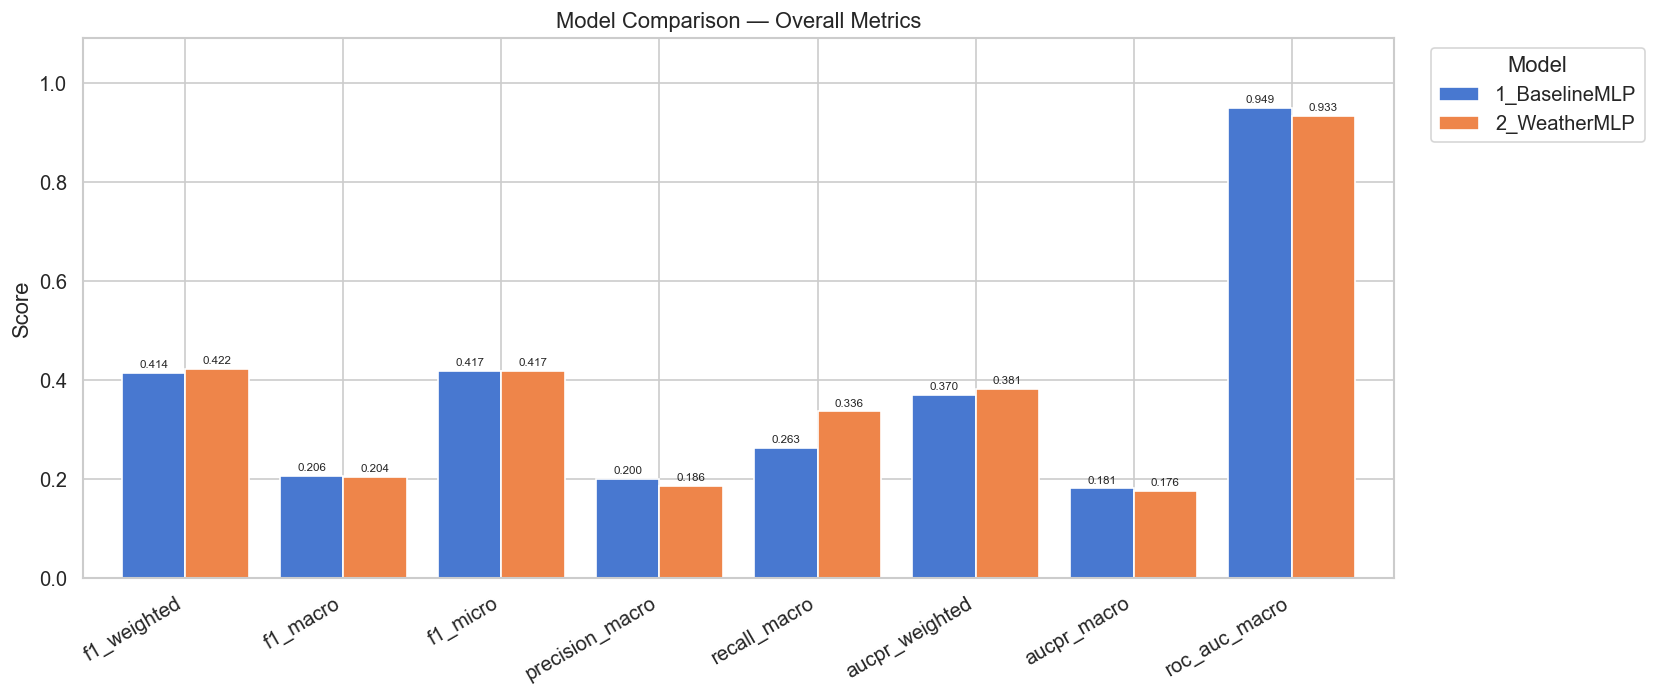

In [149]:
# ── Side-by-side overall metrics ──────────────────────────────────────
comparison_df = pd.DataFrame([v[0] for v in all_results.values()])
comparison_df = comparison_df.set_index('model')

print("\n" + "="*80)
print("                    OVERALL METRICS COMPARISON")
print("="*80)
display(comparison_df.style.format('{:.4f}').highlight_max(axis=0, color='#90ee90')
        .highlight_min(axis=0, color='#ffcccb'))

# Bar chart
metrics_to_plot = ['f1_weighted', 'f1_macro', 'f1_micro', 'precision_macro', 'recall_macro',
                   'aucpr_weighted', 'aucpr_macro', 'roc_auc_macro']
plot_df = comparison_df[metrics_to_plot].T

fig, ax = plt.subplots(figsize=(14, 6))
plot_df.plot(kind='bar', ax=ax, edgecolor='white', width=0.8)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Overall Metrics')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, comparison_df[metrics_to_plot].values.max() * 1.15)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.show()

### 5b. Per-Label F1 Comparison

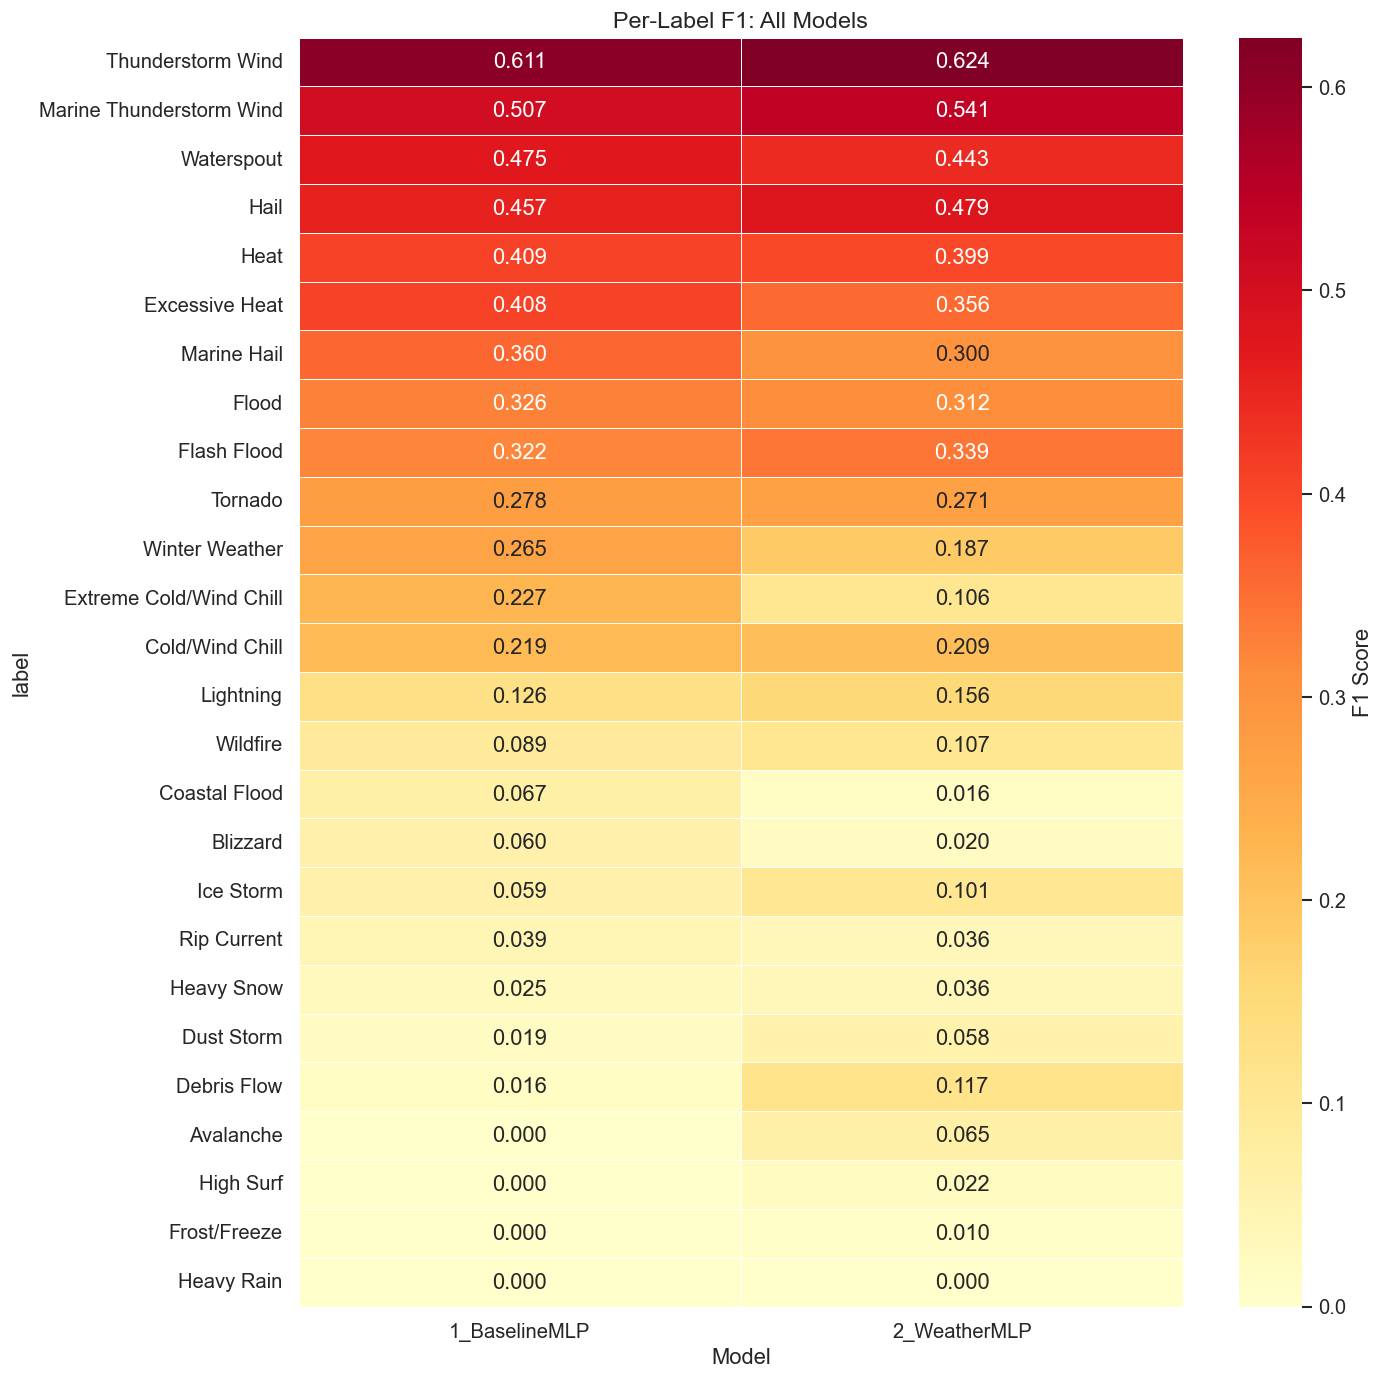


Best model per label:
  Thunderstorm Wind                    →  2_WeatherMLP
  Marine Thunderstorm Wind             →  2_WeatherMLP
  Waterspout                           →  1_BaselineMLP
  Hail                                 →  2_WeatherMLP
  Heat                                 →  1_BaselineMLP
  Excessive Heat                       →  1_BaselineMLP
  Marine Hail                          →  1_BaselineMLP
  Flood                                →  1_BaselineMLP
  Flash Flood                          →  2_WeatherMLP
  Tornado                              →  1_BaselineMLP
  Winter Weather                       →  1_BaselineMLP
  Extreme Cold/Wind Chill              →  1_BaselineMLP
  Cold/Wind Chill                      →  1_BaselineMLP
  Lightning                            →  2_WeatherMLP
  Wildfire                             →  2_WeatherMLP
  Coastal Flood                        →  1_BaselineMLP
  Blizzard                             →  1_BaselineMLP
  Ice Storm                    

In [150]:
# ── Per-label F1 heatmap across all models ────────────────────────────
perlabel_dict = {}
for mname, (_, pldf, _, _) in all_results.items():
    perlabel_dict[mname] = pldf.set_index('label')['f1']

f1_comparison = pd.DataFrame(perlabel_dict)
f1_comparison['best_model'] = f1_comparison.idxmax(axis=1)
f1_comparison = f1_comparison.sort_values(f1_comparison.columns[0], ascending=False)

fig, ax = plt.subplots(figsize=(12, max(8, len(target_names) * 0.45)))
sns.heatmap(f1_comparison.drop(columns=['best_model']).astype(float),
            annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, linewidths=.5,
            cbar_kws={'label': 'F1 Score'})
ax.set_title('Per-Label F1: All Models', fontsize=14)
ax.set_xlabel('Model')
plt.tight_layout()
plt.show()

# Who wins per label?
print("\nBest model per label:")
for label, row in f1_comparison.iterrows():
    print(f"  {label:35s}  →  {row['best_model']}")

### 5b-ii. Per-Label PR-AUC Comparison (threshold-independent)

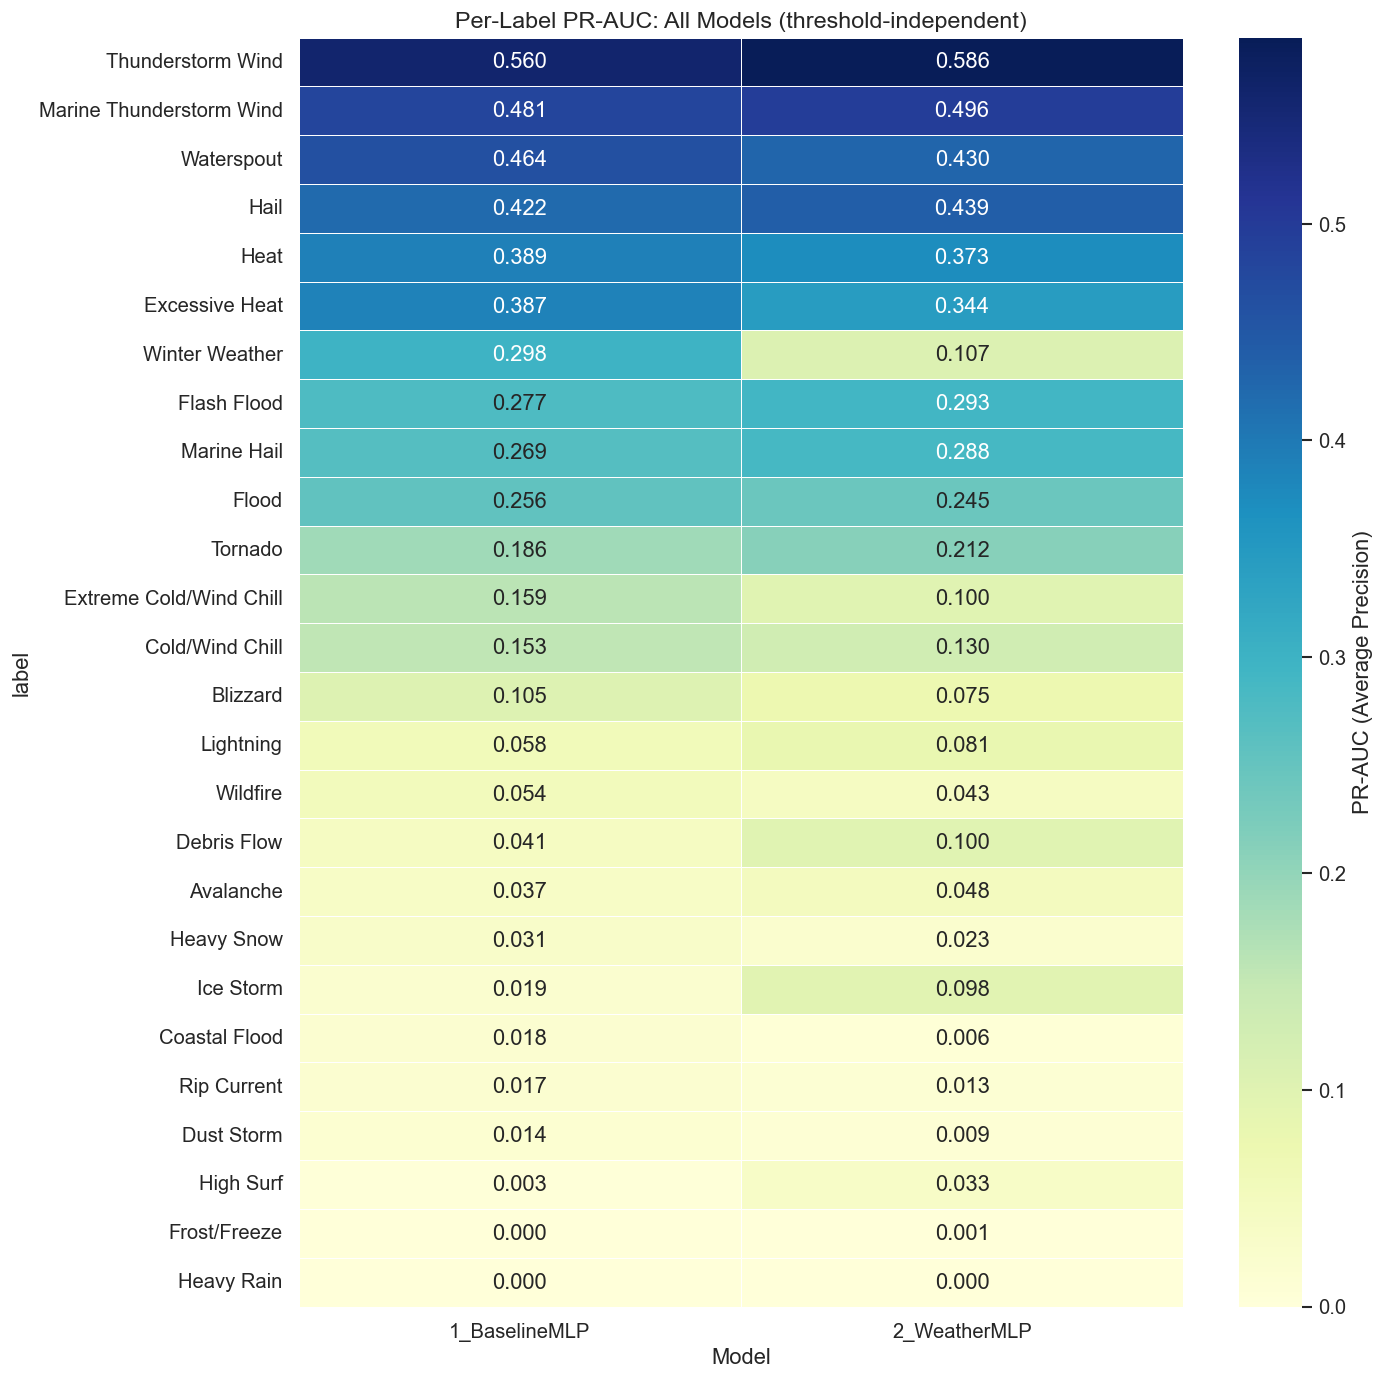


Best model per label (by PR-AUC):
  Thunderstorm Wind                    →  2_WeatherMLP
  Marine Thunderstorm Wind             →  2_WeatherMLP
  Waterspout                           →  1_BaselineMLP
  Hail                                 →  2_WeatherMLP
  Heat                                 →  1_BaselineMLP
  Excessive Heat                       →  1_BaselineMLP
  Winter Weather                       →  1_BaselineMLP
  Flash Flood                          →  2_WeatherMLP
  Marine Hail                          →  2_WeatherMLP
  Flood                                →  1_BaselineMLP
  Tornado                              →  2_WeatherMLP
  Extreme Cold/Wind Chill              →  1_BaselineMLP
  Cold/Wind Chill                      →  1_BaselineMLP
  Blizzard                             →  1_BaselineMLP
  Lightning                            →  2_WeatherMLP
  Wildfire                             →  1_BaselineMLP
  Debris Flow                          →  2_WeatherMLP
  Avalanche          

In [151]:
# ── Per-label PR-AUC heatmap across all models ────────────────────────
prauc_dict = {}
for mname, (_, pldf, _, _) in all_results.items():
    prauc_dict[mname] = pldf.set_index('label')['pr_auc']

prauc_comparison = pd.DataFrame(prauc_dict)
prauc_comparison['best_model'] = prauc_comparison.idxmax(axis=1)
prauc_comparison = prauc_comparison.sort_values(prauc_comparison.columns[0], ascending=False)

fig, ax = plt.subplots(figsize=(12, max(8, len(target_names) * 0.45)))
sns.heatmap(prauc_comparison.drop(columns=['best_model']).astype(float),
            annot=True, fmt='.3f', cmap='YlGnBu', ax=ax, linewidths=.5,
            cbar_kws={'label': 'PR-AUC (Average Precision)'})
ax.set_title('Per-Label PR-AUC: All Models (threshold-independent)', fontsize=14)
ax.set_xlabel('Model')
plt.tight_layout()
plt.show()

print("\nBest model per label (by PR-AUC):")
for label, row in prauc_comparison.iterrows():
    print(f"  {label:35s}  →  {row['best_model']}")

### 5c. Training Curves

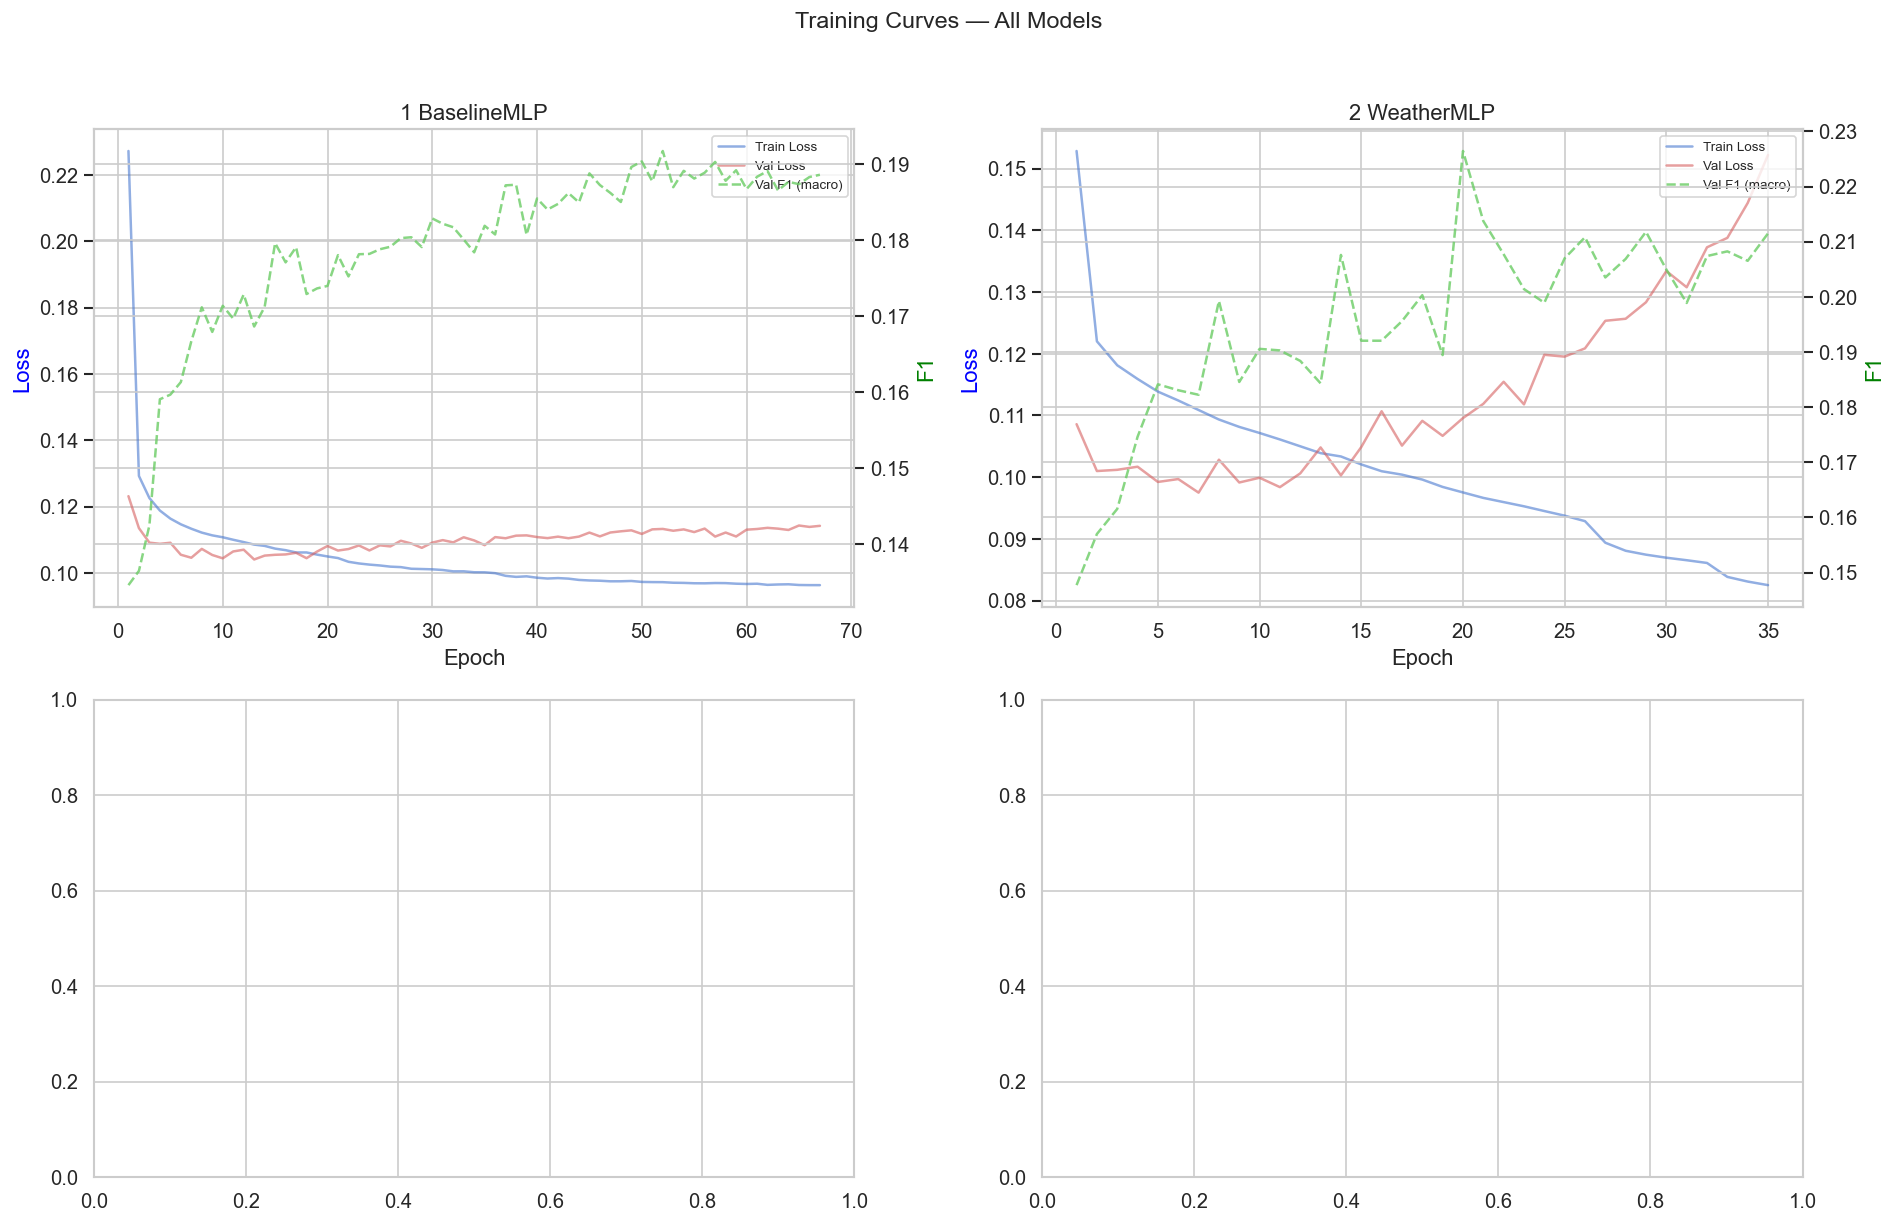

In [152]:
# ── Training curves: loss & val F1 ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (mname, (_, _, hist, _)) in zip(axes.flat, all_results.items()):
    epochs_range = range(1, len(hist['train_loss']) + 1)
    
    ax2 = ax.twinx()
    l1, = ax.plot(epochs_range, hist['train_loss'], 'b-', alpha=0.6, label='Train Loss')
    l2, = ax.plot(epochs_range, hist['val_loss'],   'r-', alpha=0.6, label='Val Loss')
    l3, = ax2.plot(epochs_range, hist['val_f1'],    'g--', alpha=0.8, label='Val F1 (macro)')
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss', color='blue')
    ax2.set_ylabel('F1', color='green')
    ax.set_title(mname.replace('_', ' '))
    ax.legend(handles=[l1, l2, l3], fontsize=8, loc='upper right')

fig.suptitle('Training Curves — All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5d. Optuna Tuning Visualisation

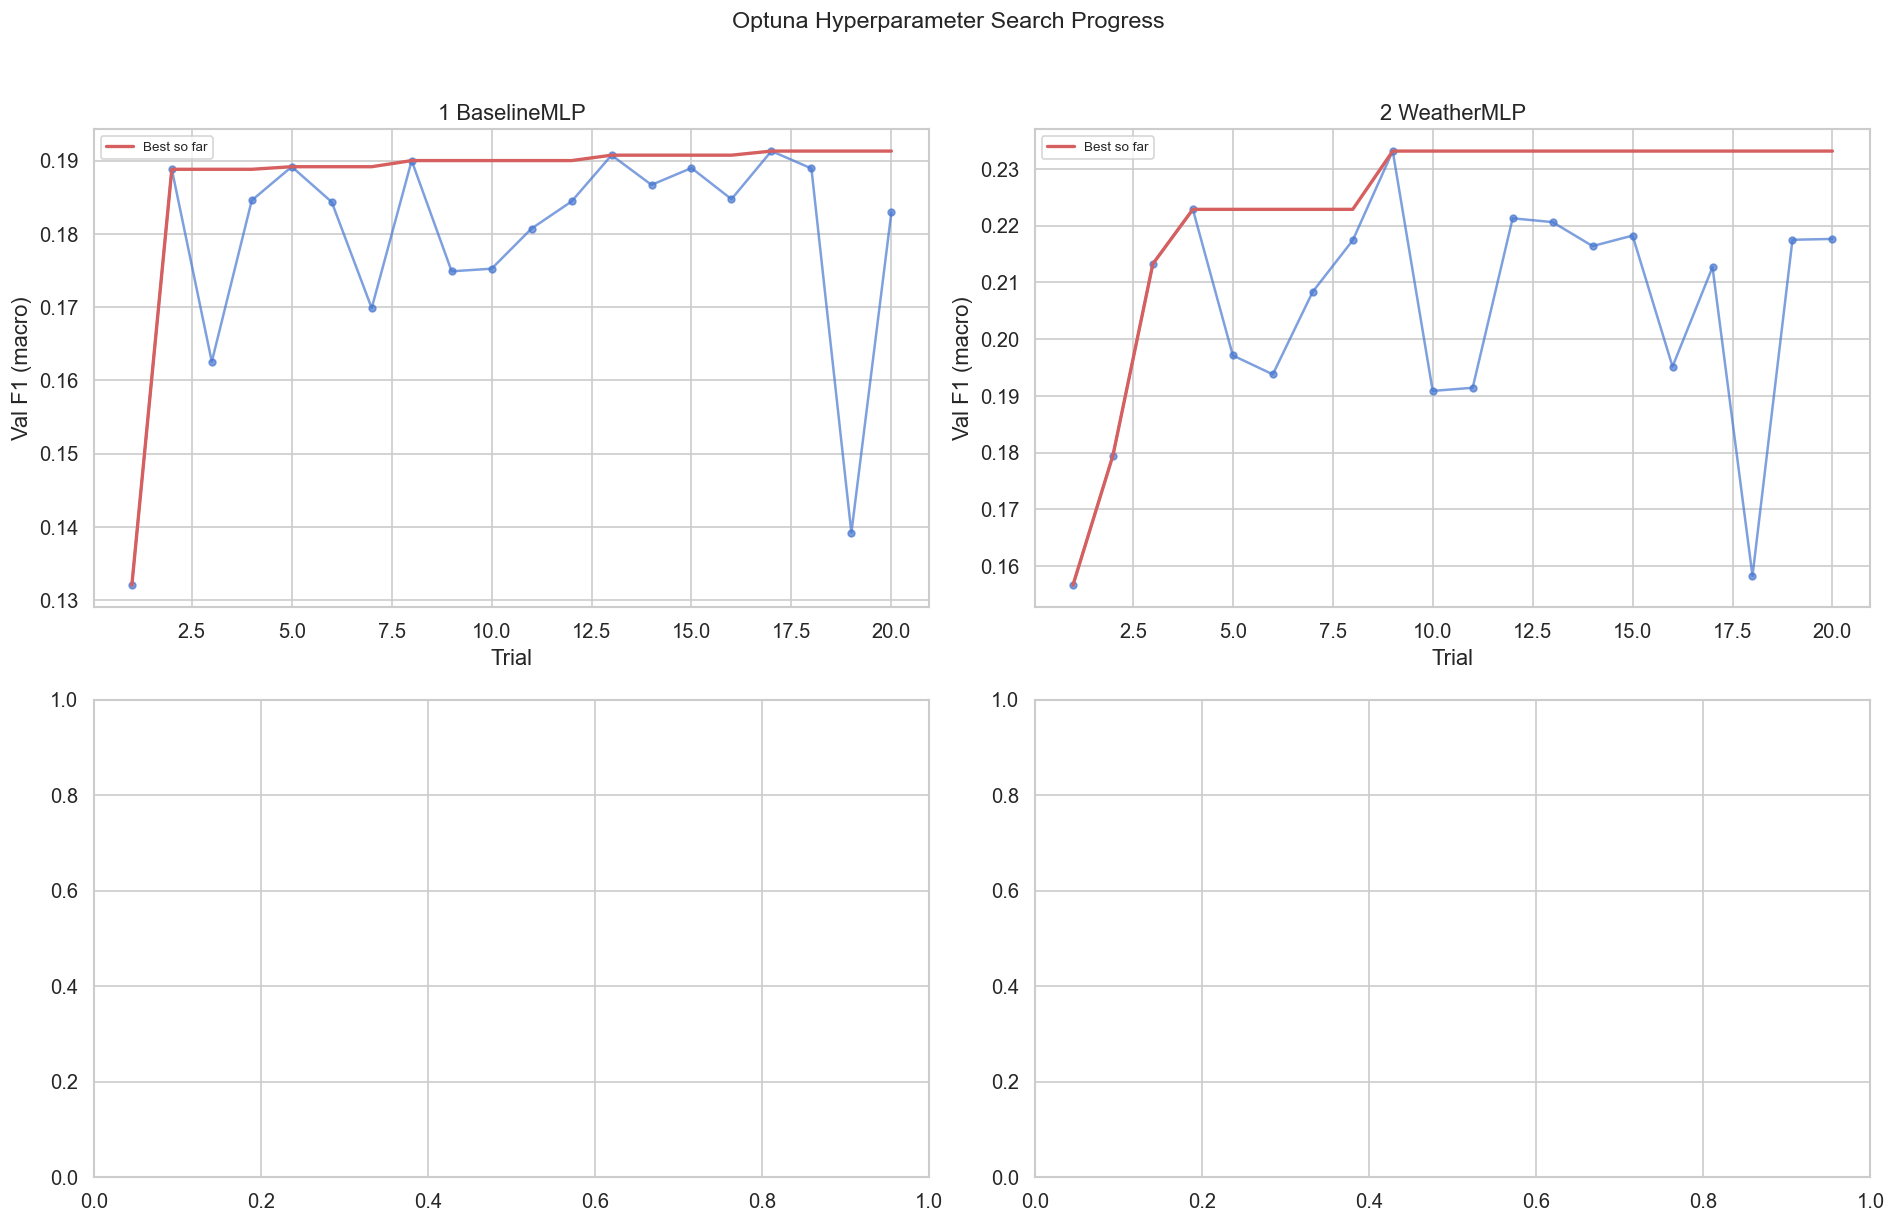

In [153]:
# ── Optuna trial history ──────────────────────────────────────────────
studies = {
    '1_BaselineMLP': study_mlp,
    '2_WeatherMLP':  study_weather_mlp,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (name, study) in zip(axes.flat, studies.items()):
    trials = study.trials
    values = [t.value for t in trials if t.value is not None]
    ax.plot(range(1, len(values)+1), values, 'o-', markersize=4, alpha=0.7)
    best_so_far = np.maximum.accumulate(values)
    ax.plot(range(1, len(values)+1), best_so_far, 'r-', lw=2, label='Best so far')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Val F1 (macro)')
    ax.set_title(name.replace('_', ' '))
    ax.legend(fontsize=8)

fig.suptitle('Optuna Hyperparameter Search Progress', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5e. Precision-Recall Curves (Best Model)

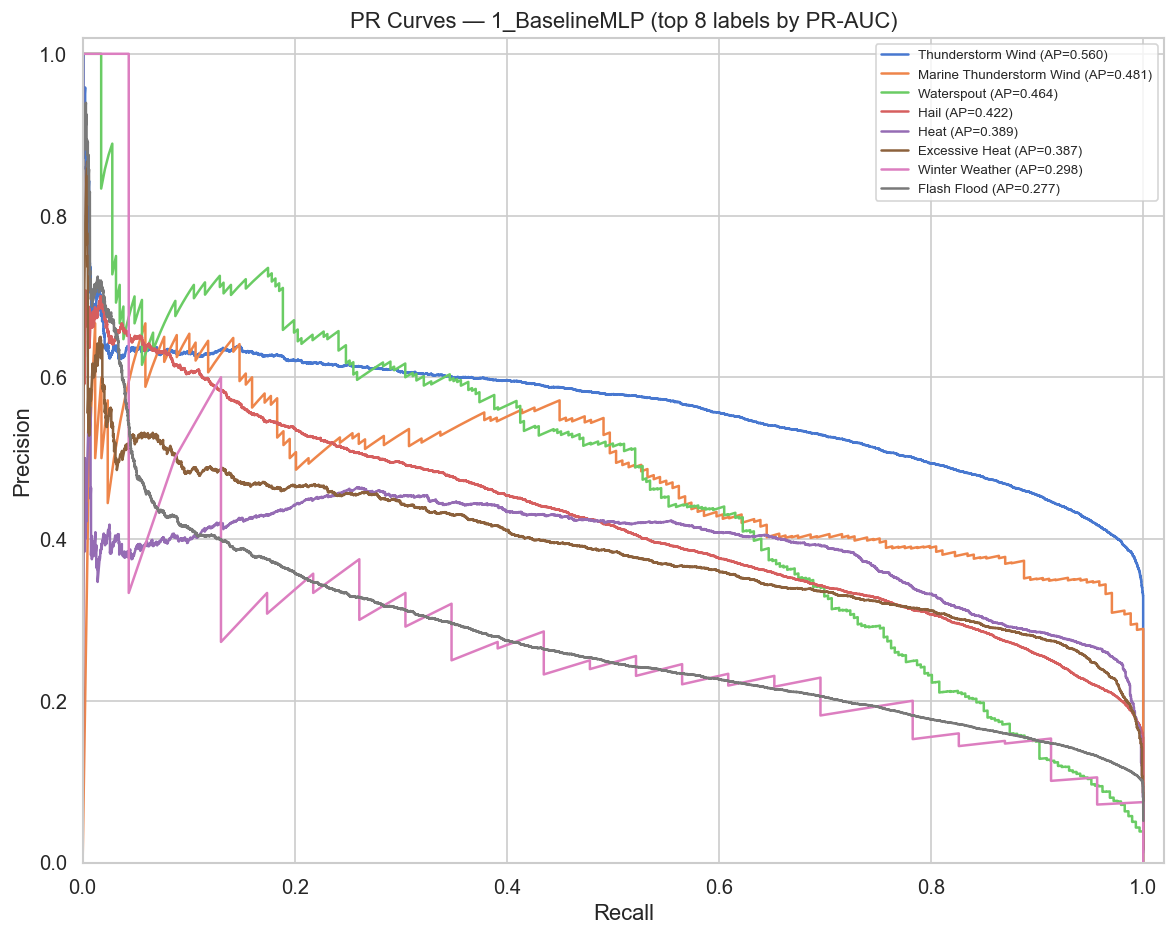

In [154]:
# ── PR curves for the best-performing model ───────────────────────────
best_model_name = comparison_df['f1_macro'].idxmax()
_, best_perlabel, _, _ = all_results[best_model_name]
# Get the matching y_prob
best_probs = {'1_BaselineMLP': y_prob_test1, '2_WeatherMLP': y_prob_test2,
              }[best_model_name]

show_pr_labels = best_perlabel.nlargest(8, 'pr_auc')['label'].tolist()

fig, ax = plt.subplots(figsize=(10, 8))
for label in show_pr_labels:
    idx = target_names.index(label)
    if y_test_raw[:, idx].sum() == 0:
        continue
    precs, recs, _ = precision_recall_curve(y_test_raw[:, idx], best_probs[:, idx])
    ap = average_precision_score(y_test_raw[:, idx], best_probs[:, idx])
    ax.plot(recs, precs, label=f'{label} (AP={ap:.3f})', lw=1.5)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'PR Curves — {best_model_name} (top 8 labels by PR-AUC)')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

### 5f. Confusion Matrices (Best Model, Top 6 Labels)

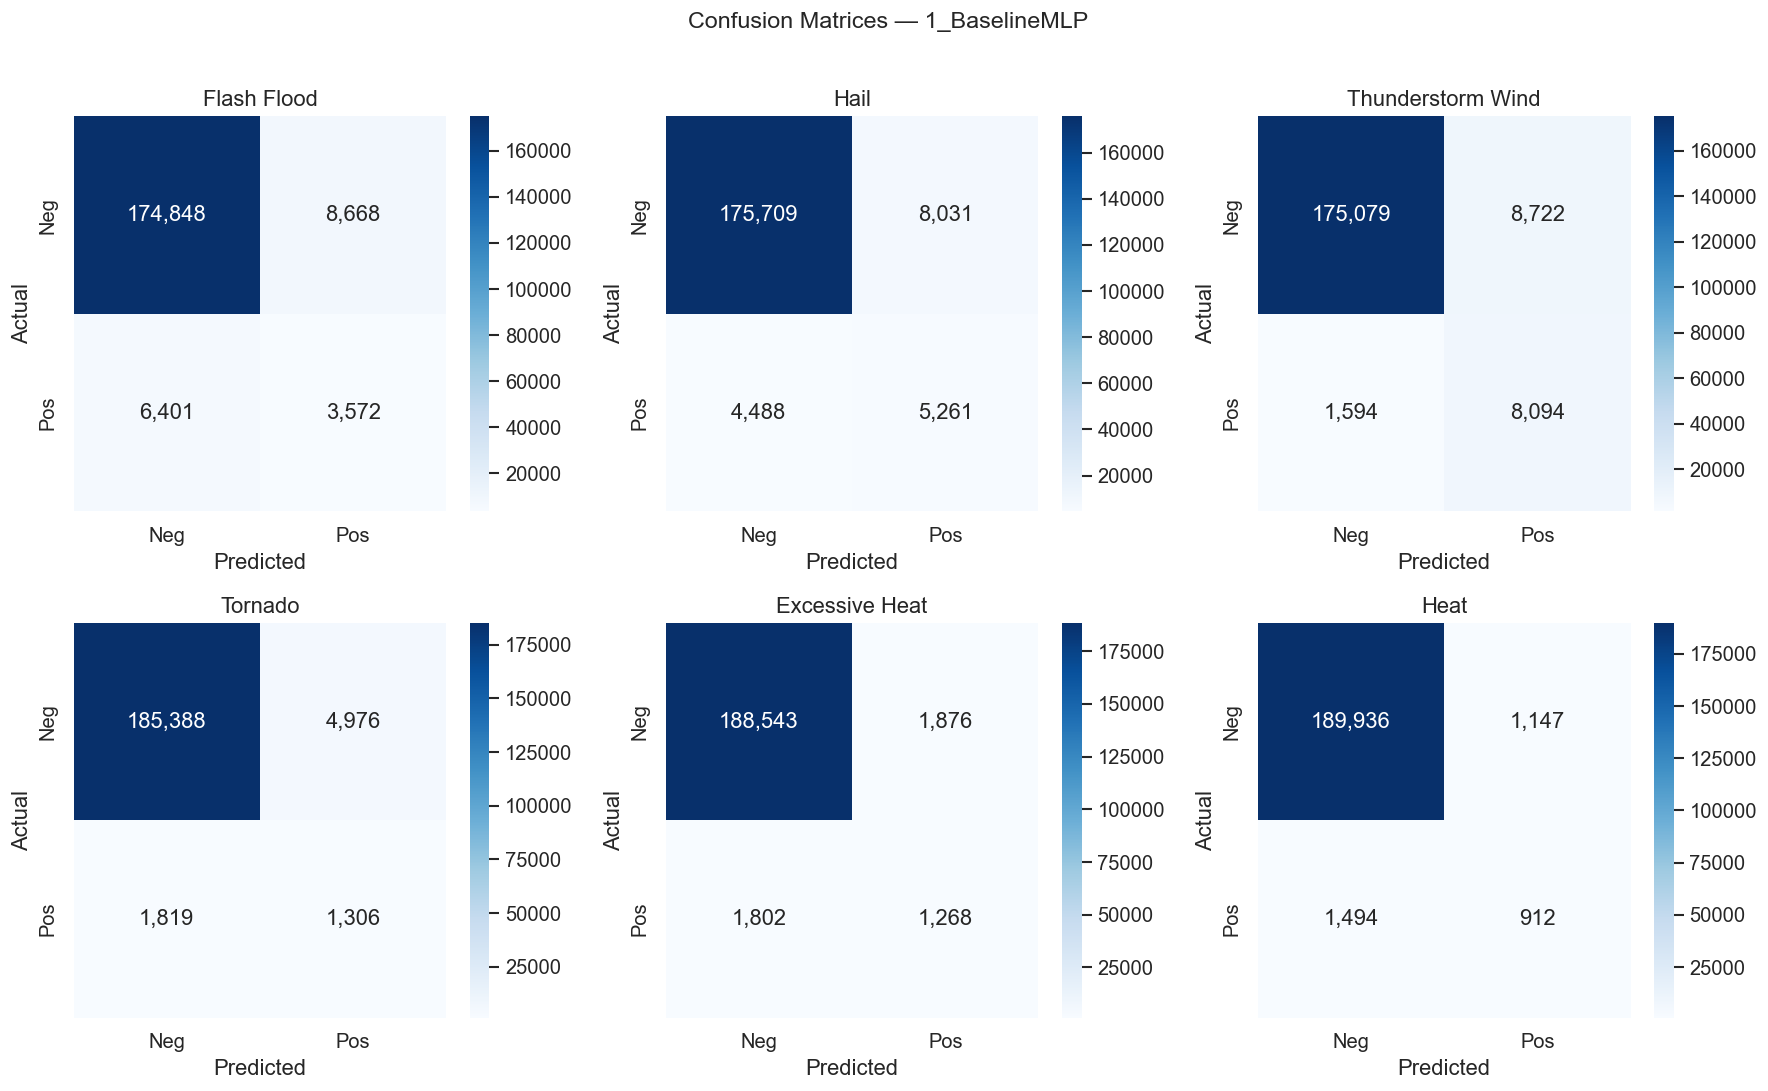

In [155]:
# ── Confusion matrices ────────────────────────────────────────────────
_, best_pl, _, best_thresh = all_results[best_model_name]
y_pred_best = (best_probs >= best_thresh).astype(int)
cm_labels = best_pl.nlargest(6, 'support')['label'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, label in zip(axes.flat, cm_labels):
    idx = target_names.index(label)
    cm = confusion_matrix(y_test_raw[:, idx], y_pred_best[:, idx])
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    ax.set_title(label)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

fig.suptitle(f'Confusion Matrices — {best_model_name}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 5g. ROC Curves (Best Model, top 8 labels)
ROC curves show the trade-off between true positive rate and false positive rate.
AUC close to 1.0 = excellent discrimination; close to 0.5 = random guessing.

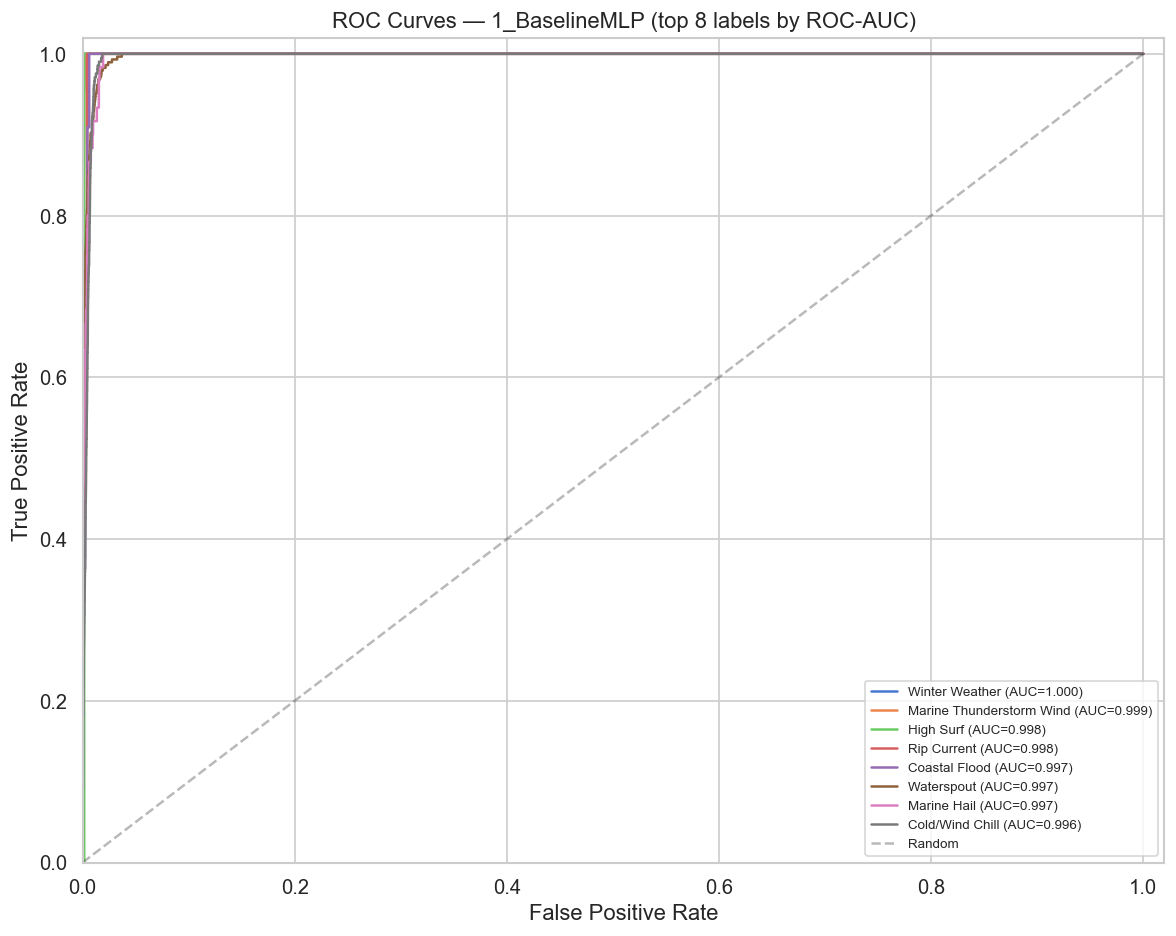

In [156]:
# ── ROC curves for the best model ──────────────────────────────────────
best_model_name_roc = comparison_df['f1_macro'].idxmax()
_, best_pl_roc, _, _ = all_results[best_model_name_roc]
best_probs_roc = {'1_BaselineMLP': y_prob_test1, '2_WeatherMLP': y_prob_test2,
                  }[best_model_name_roc]

show_roc_labels = best_pl_roc.nlargest(8, 'roc_auc')['label'].tolist()

fig, ax = plt.subplots(figsize=(10, 8))
for label in show_roc_labels:
    idx = target_names.index(label)
    if y_test_raw[:, idx].sum() == 0 or y_test_raw[:, idx].sum() == len(y_test_raw[:, idx]):
        continue
    fpr, tpr, _ = roc_curve(y_test_raw[:, idx], best_probs_roc[:, idx])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{label} (AUC={roc_auc_val:.3f})', lw=1.5)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curves — {best_model_name_roc} (top 8 labels by ROC-AUC)')
ax.legend(loc='lower right', fontsize=8)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

### 5h. Predicted Probability Distributions
Histograms of predicted P(positive) for actual positives vs negatives.
Well-calibrated models push these distributions apart — negatives near 0, positives near 1.

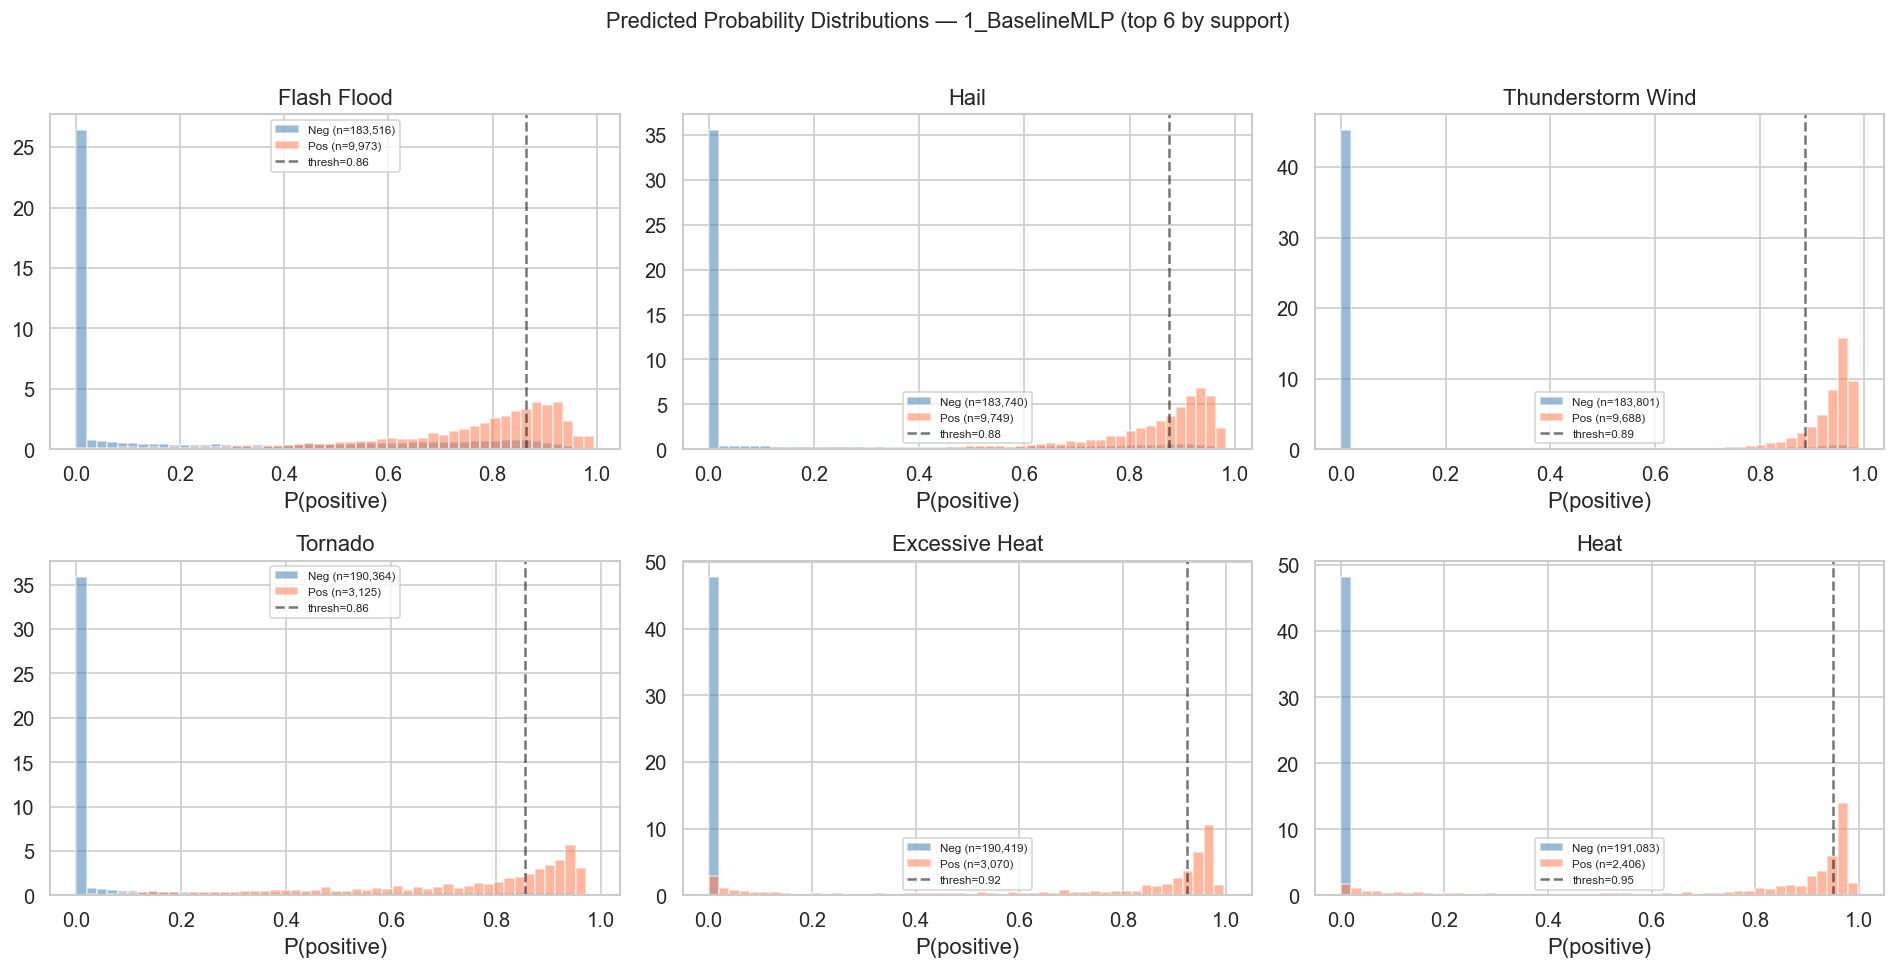

In [157]:
# ── Predicted probability distributions (best model, top 6 labels) ─────
_, best_pl_prob, _, best_thresh_prob = all_results[best_model_name_roc]
show_prob_labels = best_pl_prob.nlargest(6, 'support')['label'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, label in zip(axes.flat, show_prob_labels):
    idx = target_names.index(label)
    pos_probs = best_probs_roc[y_test_raw[:, idx] == 1, idx]
    neg_probs = best_probs_roc[y_test_raw[:, idx] == 0, idx]

    ax.hist(neg_probs, bins=50, alpha=.55, label=f'Neg (n={len(neg_probs):,})',
            color='steelblue', density=True)
    ax.hist(pos_probs, bins=50, alpha=.55, label=f'Pos (n={len(pos_probs):,})',
            color='coral', density=True)
    ax.axvline(best_thresh_prob[idx], ls='--', color='k', alpha=.6,
               label=f'thresh={best_thresh_prob[idx]:.2f}')
    ax.set_title(label)
    ax.set_xlabel('P(positive)')
    ax.legend(fontsize=7)

fig.suptitle(f'Predicted Probability Distributions — {best_model_name_roc} (top 6 by support)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 5i. Tuned Threshold Visualization
Shows the per-label optimal thresholds (tuned on val set) compared to the default 0.5.
Rare labels typically have thresholds well below 0.5.

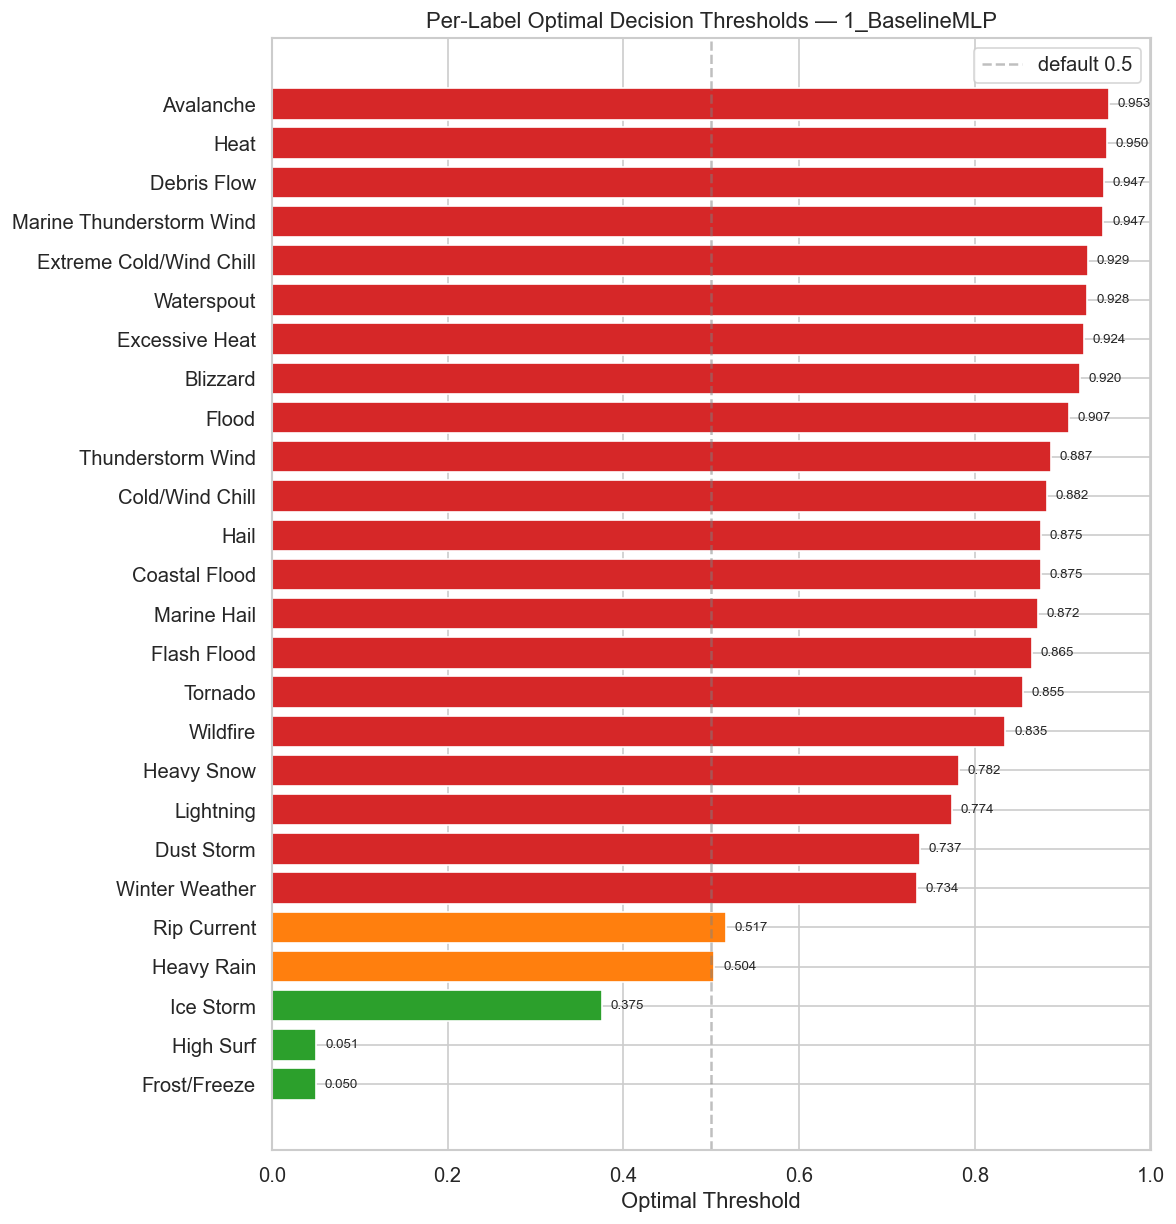

In [158]:
# ── Per-label optimal thresholds (best model) ─────────────────────────
thresh_df = pd.DataFrame({
    'label': target_names,
    'threshold': best_thresh_prob
}).sort_values('threshold', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(7, len(target_names) * 0.4)))
colors = ['#2ca02c' if t < 0.4 else '#ff7f0e' if t < 0.6 else '#d62728'
          for t in thresh_df['threshold']]
ax.barh(thresh_df['label'], thresh_df['threshold'], color=colors)
ax.axvline(0.5, ls='--', color='gray', alpha=.5, label='default 0.5')
ax.set_xlabel('Optimal Threshold')
ax.set_title(f'Per-Label Optimal Decision Thresholds — {best_model_name_roc}')
ax.legend()

for i, (lbl, t) in enumerate(zip(thresh_df['label'], thresh_df['threshold'])):
    ax.text(t + 0.01, i, f'{t:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### 5j. Per-Label F1 Bar Chart (Best Model)
Ranks each label by test-set F1 after threshold tuning. Labels with F1 near zero
may have too few training samples for the model to learn meaningful patterns.

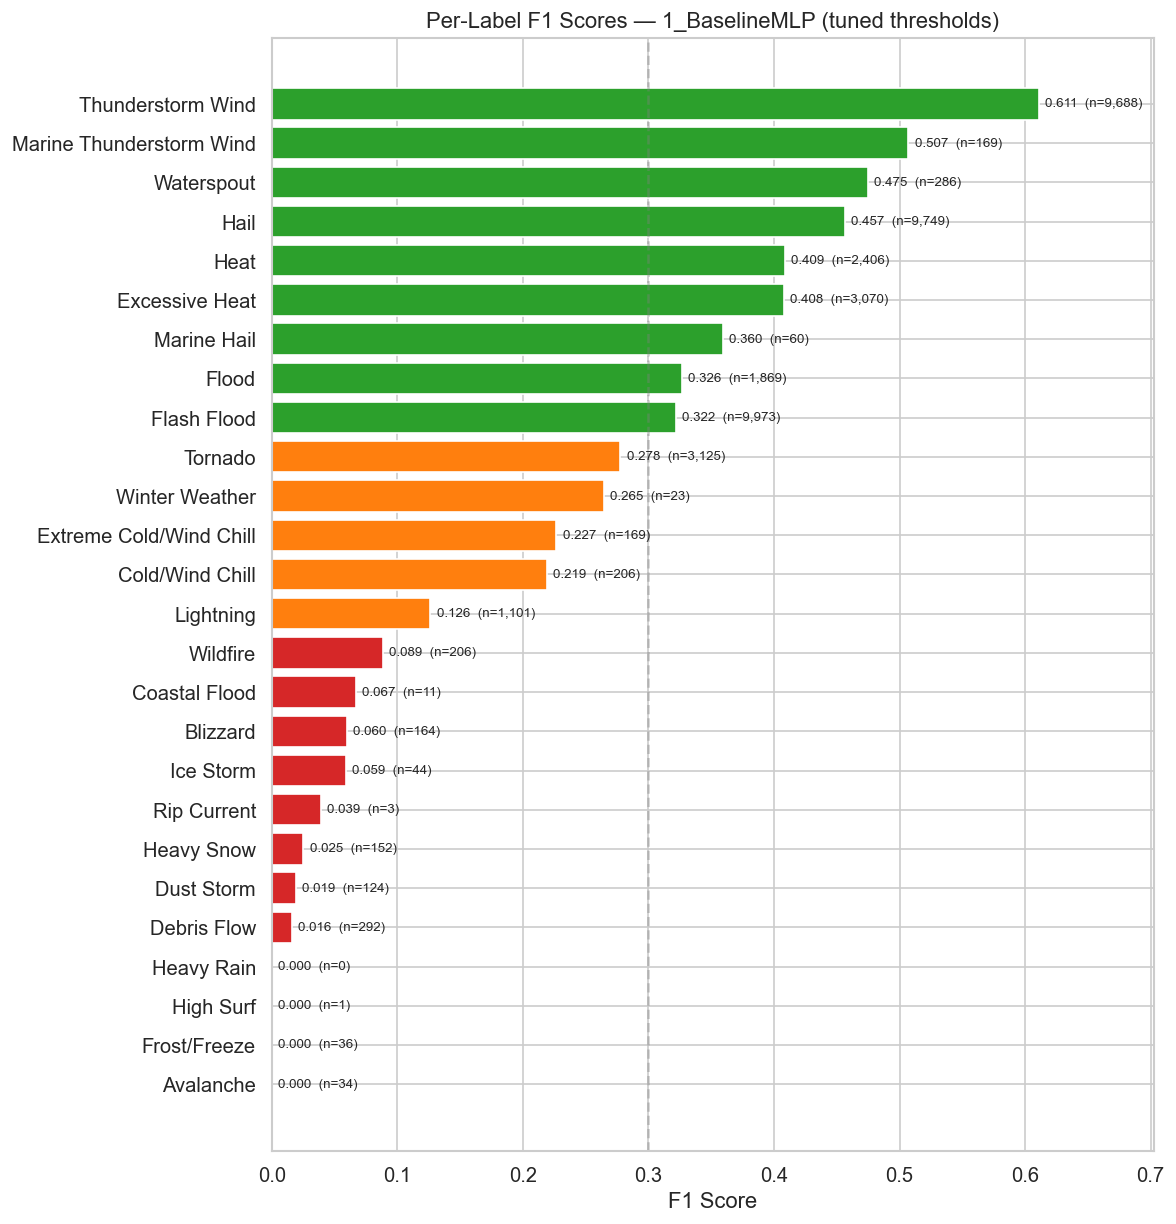

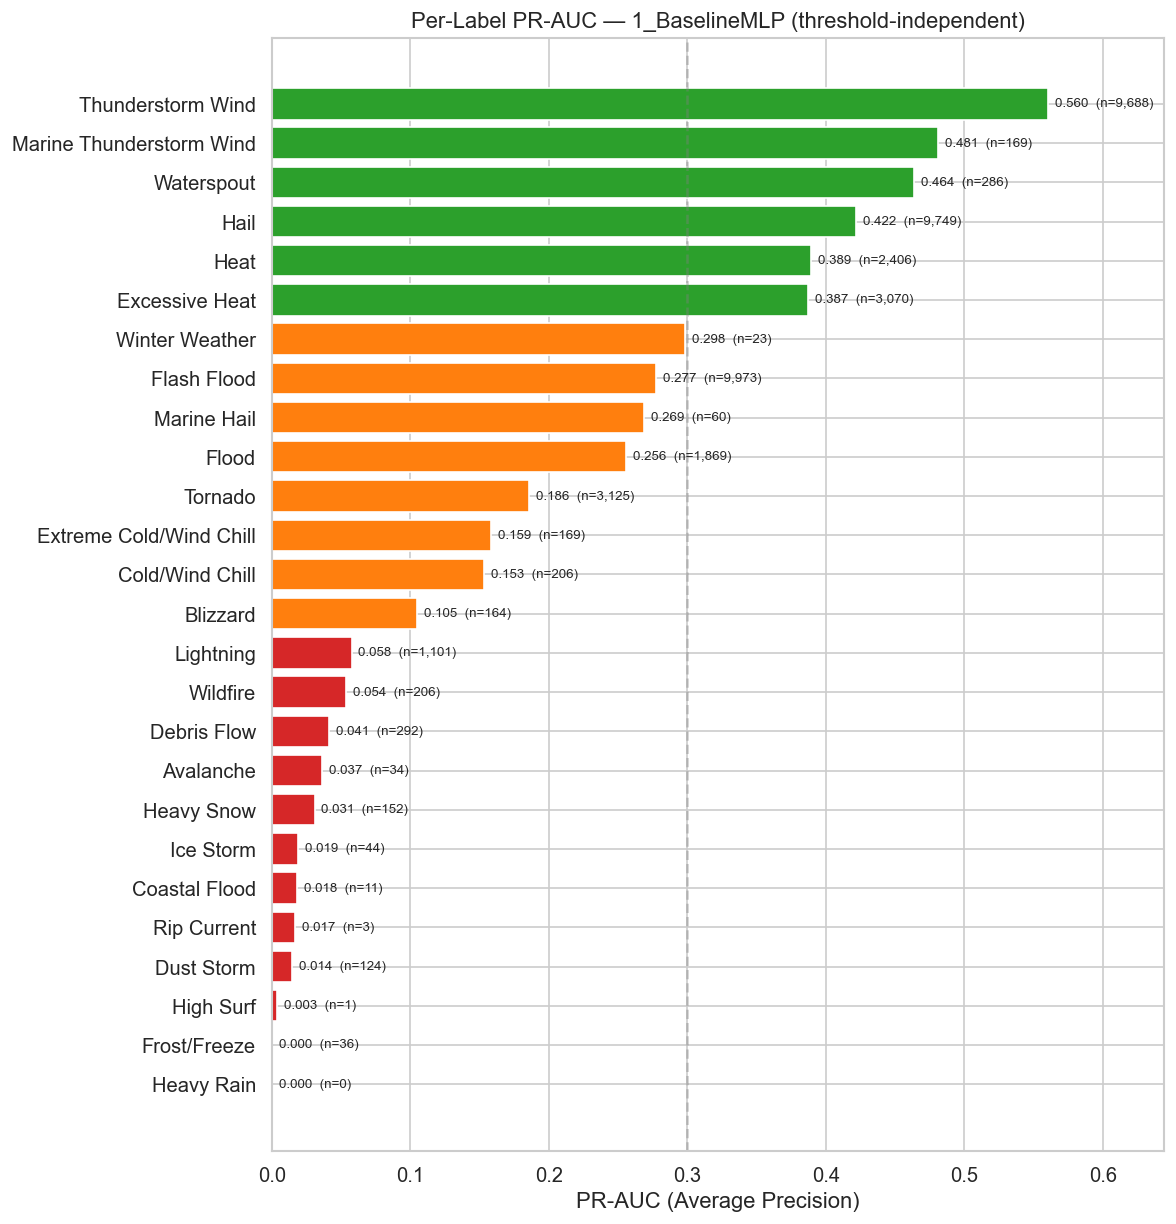

In [159]:
# ── Per-label F1 bar chart (best model) ────────────────────────────────
_, best_pl_f1, _, _ = all_results[best_model_name_roc]
df_f1 = best_pl_f1.sort_values('f1', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(8, len(target_names) * 0.4)))
colors = ['#2ca02c' if f >= 0.3 else '#ff7f0e' if f >= 0.1 else '#d62728' for f in df_f1['f1']]
ax.barh(df_f1['label'], df_f1['f1'], color=colors)
ax.set_xlabel('F1 Score')
ax.set_title(f'Per-Label F1 Scores — {best_model_name_roc} (tuned thresholds)')
ax.axvline(0.3, ls='--', color='gray', alpha=.4)
ax.set_xlim(0, max(df_f1['f1'].max() * 1.15, 0.5))

for i, (f1, sup) in enumerate(zip(df_f1['f1'], df_f1['support'])):
    ax.text(f1 + 0.005, i, f'{f1:.3f}  (n={sup:,})', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# ── Per-label PR-AUC bar chart ────────────────────────────────────────
df_prauc = best_pl_f1.sort_values('pr_auc', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(8, len(target_names) * 0.4)))
colors2 = ['#2ca02c' if a >= 0.3 else '#ff7f0e' if a >= 0.1 else '#d62728' for a in df_prauc['pr_auc']]
ax.barh(df_prauc['label'], df_prauc['pr_auc'], color=colors2)
ax.set_xlabel('PR-AUC (Average Precision)')
ax.set_title(f'Per-Label PR-AUC — {best_model_name_roc} (threshold-independent)')
ax.axvline(0.3, ls='--', color='gray', alpha=.4)
ax.set_xlim(0, max(df_prauc['pr_auc'].max() * 1.15, 0.5))

for i, (prauc_val, sup) in enumerate(zip(df_prauc['pr_auc'], df_prauc['support'])):
    ax.text(prauc_val + 0.005, i, f'{prauc_val:.3f}  (n={sup:,})', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### 5h. Weather Embedding Attention Weights

In [160]:
# ── Inspect attention weights in the weather embedding ─────────────────
def get_attention_weights(model, X_sample):
    """Extract attention weights from PhysicsInformedWeatherEmbedding."""
    we = model.weather_embed if hasattr(model, 'weather_embed') else None
    if we is None:
        return None, None
    
    we.eval()
    group_embeds = []
    group_names_active = []
    with torch.no_grad():
        for gname in we.group_names:
            if gname not in we.sub_networks:
                continue
            idx = we.feature_groups[gname]
            x_group = X_sample[:, idx]
            group_embeds.append(we.sub_networks[gname](x_group))
            group_names_active.append(gname)
        
        stacked = torch.stack(group_embeds, dim=1)
        attn_scores = we.attn_query(stacked).squeeze(-1)
        attn_weights = F.softmax(attn_scores, dim=-1)  # (B, n_groups)
    
    return attn_weights.cpu().numpy(), group_names_active

# Get weights from both weather models
attn2, groups2 = get_attention_weights(model2, X_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, attn, groups, title in [
    (axes[0], attn2, groups2, 'Model 2: WeatherMLP'),
    
]:
    if attn is None:
        ax.text(0.5, 0.5, 'No weather embedding', ha='center', va='center')
        continue
    mean_attn = attn.mean(axis=0)
    std_attn  = attn.std(axis=0)
    sorted_idx = np.argsort(mean_attn)
    
    ax.barh([groups[i] for i in sorted_idx], mean_attn[sorted_idx],
            xerr=std_attn[sorted_idx], color='coral', edgecolor='white', capsize=3)
    ax.set_xlabel('Mean Attention Weight')
    ax.set_title(title)
    for i, idx in enumerate(sorted_idx):
        ax.text(mean_attn[idx] + std_attn[idx] + 0.005, i,
                f'{mean_attn[idx]:.3f}', va='center', fontsize=9)

fig.suptitle('Weather Embedding — Learned Attention over Feature Groups', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nInterpretation: Higher attention weight = the model finds this feature group")
print("more useful for cascade prediction after physics-informed encoding.")

NameError: name 'X_sample' is not defined

---
## 6. Final Summary & Conclusion

In [161]:
# ── Final comparison table ─────────────────────────────────────────────
print('╔══════════════════════════════════════════════════════════════════════════════════════════╗')
print('║                       NEURAL NETWORK MODEL COMPARISON SUMMARY                        ║')
print('╠══════════════════════════════════════════════════════════════════════════════════════════╣')
print(f'║  {"Model":25s}  {"F1-w":>6s}  {"F1-M":>5s}  {"F1-m":>5s}  '
      f'{"Prec-M":>7s}  {"Rec-M":>6s}  {"AUCPR-w":>7s}  {"AUCPR-M":>7s}  '
      f'{"ROC-M":>6s}  {"HL":>6s}  ║')
print('║' + '-' * 90 + '║')
for mname, (res, _, _, _) in all_results.items():
    print(f'║  {mname:25s}  {res["f1_weighted"]:6.4f}  {res["f1_macro"]:5.4f}  '
          f'{res["f1_micro"]:5.4f}  {res["precision_macro"]:7.4f}  '
          f'{res["recall_macro"]:6.4f}  {res["aucpr_weighted"]:7.4f}  '
          f'{res["aucpr_macro"]:7.4f}  {res["roc_auc_macro"]:6.4f}  '
          f'{res["hamming_loss"]:6.4f}  ║')
print('╚══════════════════════════════════════════════════════════════════════════════════════════╝')

# Determine best
best_name = max(all_results.keys(), key=lambda k: all_results[k][0]['f1_macro'])
print(f'\n  Best model by macro-F1: {best_name}')
print(f'  XGBoost baseline (from notebook 02): F1-weighted ≈ 0.4697, F1-macro ≈ 0.2963')

# Model parameter counts
print('\n  Parameter counts:')
for name, mdl in [('1_BaselineMLP', model1), ('2_WeatherMLP', model2),
                   ]:
    n_params = sum(p.numel() for p in mdl.parameters())
    print(f'    {name:25s}  {n_params:>10,} params')

╔══════════════════════════════════════════════════════════════════════════════════════════╗
║                       NEURAL NETWORK MODEL COMPARISON SUMMARY                        ║
╠══════════════════════════════════════════════════════════════════════════════════════════╣
║  Model                        F1-w   F1-M   F1-m   Prec-M   Rec-M  AUCPR-w  AUCPR-M   ROC-M      HL  ║
║------------------------------------------------------------------------------------------║
║  1_BaselineMLP              0.4144  0.2062  0.4174   0.1999  0.2630   0.3701   0.1807  0.9493  0.0121  ║
║  2_WeatherMLP               0.4221  0.2042  0.4174   0.1856  0.3364   0.3811   0.1758  0.9328  0.0128  ║
╚══════════════════════════════════════════════════════════════════════════════════════════╝

  Best model by macro-F1: 1_BaselineMLP
  XGBoost baseline (from notebook 02): F1-weighted ≈ 0.4697, F1-macro ≈ 0.2963

  Parameter counts:
    1_BaselineMLP                 220,762 params
    2_WeatherMLP              

In [162]:
# ── Save all models ────────────────────────────────────────────────────
SAVE_DIR = Path('../models/neural_nets')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

for name, mdl in [('model1_baseline_mlp', model1), ('model2_weather_mlp', model2),
                   ]:
    torch.save(mdl.state_dict(), SAVE_DIR / f'{name}.pt')

# Save results
with open(SAVE_DIR / 'results_summary.pkl', 'wb') as f:
    pickle.dump({
        'all_results': {k: (v[0], v[1], v[3].tolist()) for k, v in all_results.items()},
        'comparison_df': comparison_df,
        'best_params': {
            '1_BaselineMLP': study_mlp.best_params,
            '2_WeatherMLP':  study_weather_mlp.best_params,
    
        }
    }, f)

print(f"Models & results saved to {SAVE_DIR}/")

Models & results saved to ../models/neural_nets/


## Conclusion

This notebook implemented and compared four neural network architectures for multilabel cascading disaster prediction. All models were tuned via Optuna (30 trials each) and evaluated using the same chronological train/val/test split and per-label threshold tuning as the XGBoost baseline.

**Key architectural innovations:**

- **Physics-Informed Weather Embedding**: A trainable module that separates features into meteorological groups (temporal-cyclical, spatial, severity, event-type, cascade-transition probabilities, historical context) and applies group-specific sub-networks: cyclical gating for periodic time features, RBF spatial transforms for geographic coordinates, and softmax normalization for cascade probability vectors. Group representations are fused via learned attention weights, giving the model an inductive bias toward physically meaningful feature interactions.


**What to look for in the results:**
- Do weather embeddings improve over raw-feature MLPs?
- Which feature groups receive the highest attention weights?
- How do the neural net models compare to the XGBoost baseline (F1-weighted ≈ 0.47, F1-macro ≈ 0.30)?